# Linear Regression from First First Principles (House Price Prediction)

# Objective: To quantify the relationship between demographic, geographic, and median house values in California using multivariate linear regression.

The model will be implemented from scratch using the normal equation and numerical optimization (gradient descent), with emphasis on mathematical formulation, convergence behavior, and feature impact analysis. Afterwards, Scikit-Learn will be used to compare and contrast the results from the two prior implementations.

# Problem Definition

The main goal of this project is to build a multiple linear regression model that accurately predicts the median house value (in $100,000 units) for California census block groups (districts) based on a set of demographic, housing, and geographic features.

This is formulated as a supervised learning regression task. The model assumes a linear relationship between the input features and the target variable, enabling predictions on unseen data. Model performance is evaluated using Root Mean Squared Error (RMSE), which penalizes large errors more heavily. Evaluation is performed on a held-out test set to assess generalization.

The model minimizes the Mean Squared Error (MSE) cost function during training. Features exhibiting skewness are log-transformed prior to modeling, and standardization is applied to ensure stable gradient-based optimization.

**Task Type:** Supervised regression (predict a continuous target variable).

---

## Dataset Overview

- 20,640 samples (census block groups in California, based on 1990 census data).
- 8 numerical features + 1 target.
- Contains missing values in the `total_bedrooms` feature (imputed using median substitution prior to modeling).
- Target values range roughly from `$15,000` to `$500,000` (i.e., `0.15` to `5.0` in `$100,000` units).
- The target variable is capped at `$500,001`, introducing an artificial ceiling effect that may limit model accuracy for high-value districts.


---

## Features (Predictors, X)

- **(MedInc)**     - Median income in the block group (in tens of thousands of dollars).
- **(HouseAge)**   - Median house age in the block group.
- **(AveRooms)**   - Average number of rooms per household.
- **(AveBedrms)**  - Average number of bedrooms per household.
- **(Population)** - Total population in the block group.
- **(AveOccup)**   - Average number of household members (occupancy).
- **(Latitude)**   - Block group latitude.
- **(Longitude)**  - Block group longitude.

## Target (y)

- **(MedHouseVal)** - Median house value for the district (in $100,000 units).

---

# Exploratory Data Analysis (EDA) and Data Preprocessing
Objective: To understand the dataset, identify patterns, detect anomalies, and validate assumptions, then clean and transform the data.

In [39]:
# importing dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# settings
sns.set(style="whitegrid")
%matplotlib inline

Imported Dependencies while setting the graphs to display with whitegrids and ensuring the plots are rendered in this interface.

In [40]:
# Load url and passing to Pandas
url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"
housing = pd.read_csv(url) #Using Pandas .read_csv function to parse the url into a csv file

housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Basic Data Inspection:

In [41]:
housing.shape
housing.columns
housing.info()
housing.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


The features total_rooms, total_bedrooms, population, and households exhibit strong right skewness, while median_income is moderately skewed. The housing_median_age feature appears approximately symmetric.

Significant high-value observations are present in several features. These are likely reflective of high-density urban regions rather than true anomalies.

The target variable (median_house_value) is artificially capped at 500001, introducing a ceiling effect rather than a natural outlier. This may distort the distribution and limit model performance for high-value predictions.

The dataset exhibits substantial skewness and scale disparities across features. This suggests that transformations such as logarithmic scaling may be beneficial to stabilize variance and reduce the influence of extreme values.

Linear regression does not necessarily require normality of features; however, skewed distributions and extreme values can negatively impact model performance and optimization.

### Inspection and handling of Missing Values:

In [42]:
housing.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Apparently, there are 207 rows where total_bedrooms has missing values (NaN).
I could handle it by removing those rows, but I don't want to lose the rows, so I'll replace with rows with the median value (as data is skewed) in that column, to reduce the impact of potential outliers.

In [43]:
housing['total_bedrooms'] = housing['total_bedrooms'].fillna(housing['total_bedrooms'].median())

# Data Visualization:

## Histogram to Visualize Log Transormation effect:

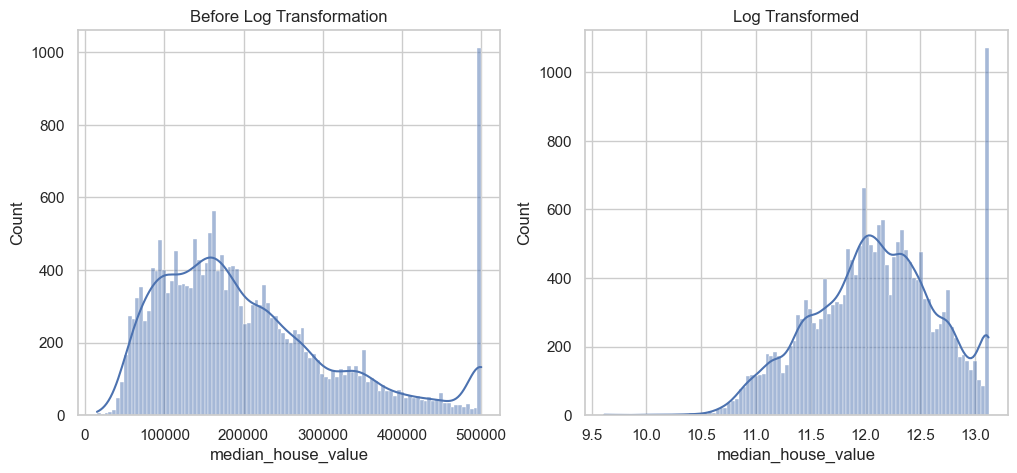

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(housing['median_house_value'], bins=100, kde=True, ax=ax[0])
ax[0].set_title("Before Log Transformation")

sns.histplot(np.log1p(housing['median_house_value']), bins=100, kde=True, ax=ax[1])
ax[1].set_title("Log Transformed")

plt.show()

#housing['median_house_value'].skew()
#housing['median_house_value_log'].skew()

This plot shows that the distribution of median house values is right-skewed, indicating that most districts have relatively low to moderate house prices, while a small number of districts have significantly higher prices that stretch the distribution to the right.

Housing markets are naturally uneven, most regions are affordable to moderate, while a few high-demand locations (urban centers, coastal areas) command significantly higher prices, inflating the upper tail.

Approximately 1,000+ districts are recorded at the `$500,001` ceiling; these are censored values introduced by the data collection process, not naturally occurring outliers. They can disproportionately influence the loss function and bias the regression line upward in the high-value range.

After applying the log transformation, the distribution became significantly less right-skewed, though it retains a bimodal shape and a notable spike at the upper end due to the `$500,001` ceiling effect. The prominent spike at the right tail of the log transformed distribution corresponds to the artificially capped values at \$500,001, which compress into a single log-space bin at approximately 13.1.

The log-transformed target variable exhibits a skewness of approximately -0.17, indicating a nearly symmetric distribution with a very mild left skew. This confirms that the transformation successfully reduced the original right skewness and improved distributional balance, making the data more suitable for linear regression modeling.

100 bins were used for the histograms to capture distributional detail at the cost of increased visual noise. The log transformed histogram reveals a smoother, more Gaussian shape. A numerical skewness query confirms the true distributional shift.

## Feature vs target relationships:

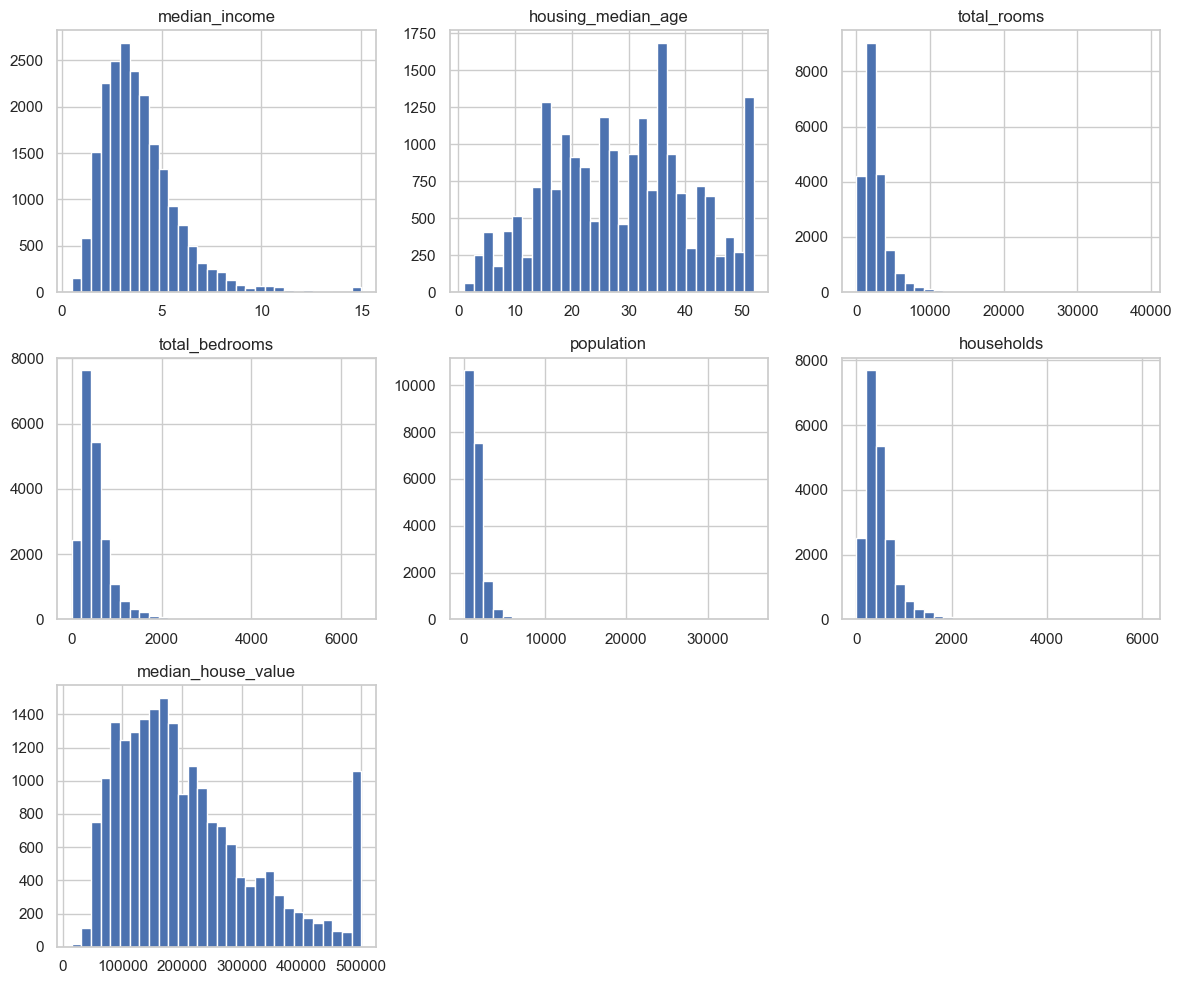

In [45]:
cols = ["median_income", "housing_median_age", "total_rooms", "total_bedrooms", "population",
       "households", "median_house_value"]


housing[cols].hist(figsize=(12,10), bins=30)
plt.tight_layout()
plt.show()

Most features exhibit right-skewed distributions, with the bulk of values concentrated at lower ranges and long tails extending toward higher values.

Right-Skewed Features (The "Long Tails"):

The following plots all show a high concentration of data on the left with a long tail stretching to the right.

total_rooms, total_bedrooms, population, households: These represent the scale of a geographical block. Most blocks are relatively small, but a few "outlier" blocks have massive numbers of rooms or residents.

median_income: The x-axis is expressed in tens of thousands of dollars, so the bulk of districts fall between `$20,000` and `$60,000` in median income, with a long tail extending toward $150,000 for high-income areas.

Capped data ("The Clipping Effect")

median_house_value: There is a huge spike at 500,000 dollars. This means any house worth more than 500k was recorded as 500,001. 
This is a critical detail because the model might struggle to predict values above this "artificial ceiling."

housing_median_age: Exhibits two distinct characteristics: a multi-modal distribution with construction boom peaks visible around 15–20 and 30–35 years, suggesting different periods of rapid development across California, and an artificial spike at 52 years where all neighborhoods older than 52 were grouped into a single bin. The same censoring effect seen in the target variable.

<Axes: xlabel='median_income', ylabel='median_house_value'>

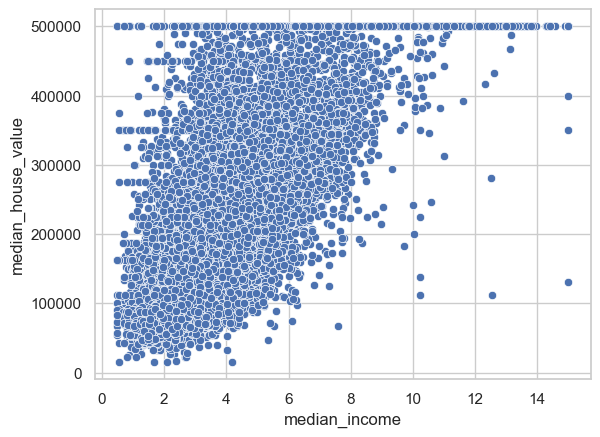

In [46]:
sns.scatterplot(x='median_income', y='median_house_value', data=housing)

## Looking at the scatter plot of Median Income vs. Median House Value, there is a clear upward, linear trend. This justifies Linear Regression as a starting model because of its high interpretability and efficiency.

The Pearson correlation between the two variables is approximately 0.68, confirming a strong positive linear relationship. As median income increases, median house value generally tends to increase. This makes intuitive sense; wealthier districts typically command higher housing prices.

The horizontal band of points clustered at $500,001 across the top of the plot is a direct visual manifestation of the target ceiling effect. Districts of varying income levels are all recorded at the same maximum value, distorting the upper end of the relationship and masking what would otherwise be a stronger and cleaner positive trend at the high-income end.

The spread of house values is also noticeably wider at lower income levels and narrows at higher income levels, suggesting heteroscedasticity. The variance of the target is not constant across the range of median income. This violates one of the core assumptions of linear regression and partially explains why the model's residuals are larger for certain prediction ranges, as observed in the residual analysis.

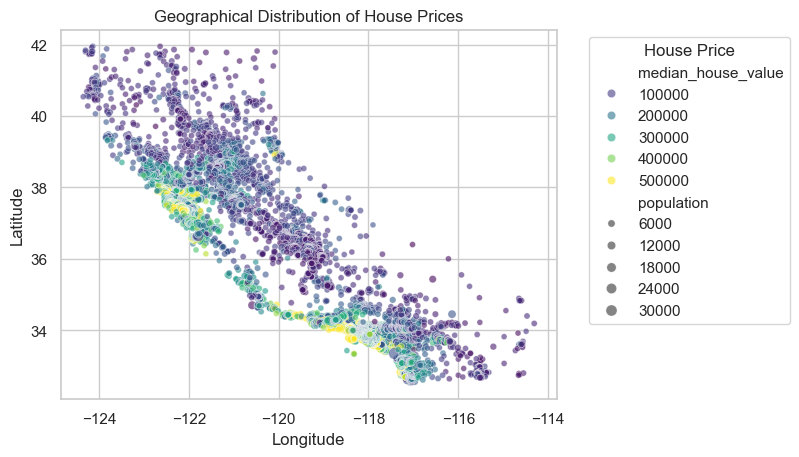

In [47]:
sns.scatterplot(
    data=housing,
    x="longitude",
    y="latitude",
    hue="median_house_value",
    size='population', 
    palette="viridis",          
    alpha=0.6                  
)

plt.title("Geographical Distribution of House Prices")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="House Price", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

The above spatial scatter plot encodes latitude and longitude as axis positions, median house value as color, and block group population as dot size, revealing strong geographic clustering of house prices across California.

High-value districts represented by yellow and green dots are concentrated in two clearly identifiable regions: the San Francisco Bay Area corridor around longitude -122, latitude 37–38, and the Los Angeles and San Diego coastal strip around longitude -118 to -117, latitude 33–34. These are California's most economically active urban centers, where demand for housing is structurally high.

A sharp price gradient is visible as distance from the coast increases. Inland districts represented by purple dots cluster at consistently lower values, while the coastal strip concentrates the highest prices. This coastal-to-inland price decay is steep and spatially structured, not linear, which is precisely why latitude and longitude perform poorly as raw numeric predictors in a linear model. A value at longitude -122 is not simply "worth more" than one at -120 in any linear sense, deductively, the relationship is geographic and spatial.

The dot size encoding reveals that population size is distributed across both high and low value areas with no clear directional pattern, confirming that block group population alone is not a reliable predictor of house value.

This plot is direct visual evidence for two of the model's core limitations which is the linear assumption applied to inherently non-linear geographic relationships, and the coarseness of raw latitude and longitude as substitutes for true spatial features. Distance-to-coast or cluster-based geographic encoding would carry significantly more predictive signal.

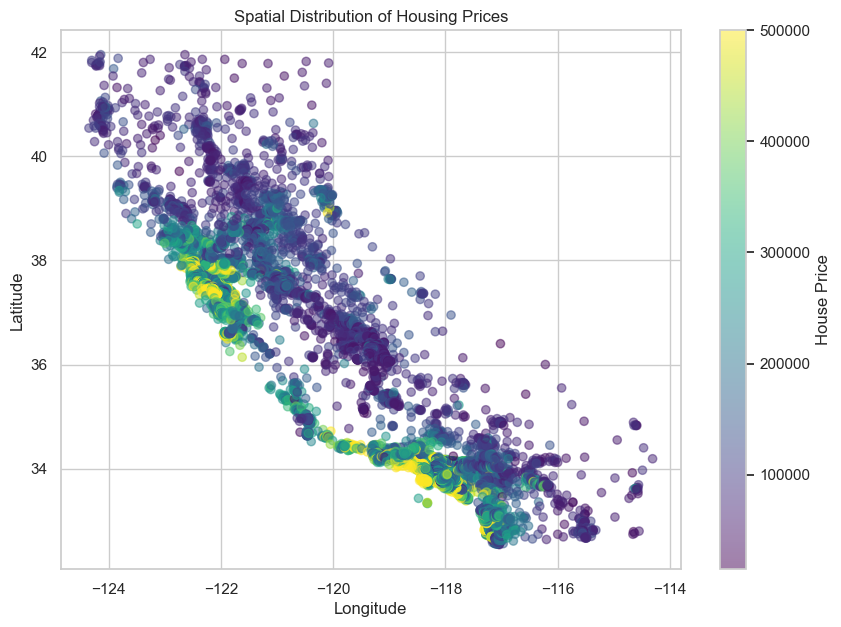

In [48]:
plt.figure(figsize=(10, 7))

plt.scatter(
    housing["longitude"],
    housing["latitude"],
    c=housing["median_house_value"],
    cmap="viridis",
    alpha=0.5
)

plt.colorbar(label="House Price")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of Housing Prices")

plt.show()

The above spatial scatter plot uses a continuous color scale to encode median house value across California census block groups, with yellow representing the highest values approaching `$500,001` and deep purple representing the lowest values near `$15,000`.

This plot extends the insight from the previous geographic visualization. Where the prior plot used a categorical color scale and population-encoded dot sizes to highlight discrete price bands, this continuous color scale reveals the full price gradient more smoothly ie. mid-range pricing patterns and transitional zones between expensive and affordable regions are more clearly visible here.

The most expensive districts hug the Pacific coastline and cluster tightly around two major metropolitan corridors: the San Francisco Bay Area around longitude -122, latitude 37–38, and the Greater Los Angeles and San Diego region around longitude -118 to -117, latitude 33–34.

Moving inland, the color transitions sharply toward teal and purple, particularly across the Central Valley — the broad inland agricultural region stretching between roughly longitude -119 and -121 — where housing is significantly more affordable. Isolated yellow and green dots appearing inland represent anomalies, likely smaller high-demand communities or data artifacts worth investigating further.

## Multicollinearity Detection

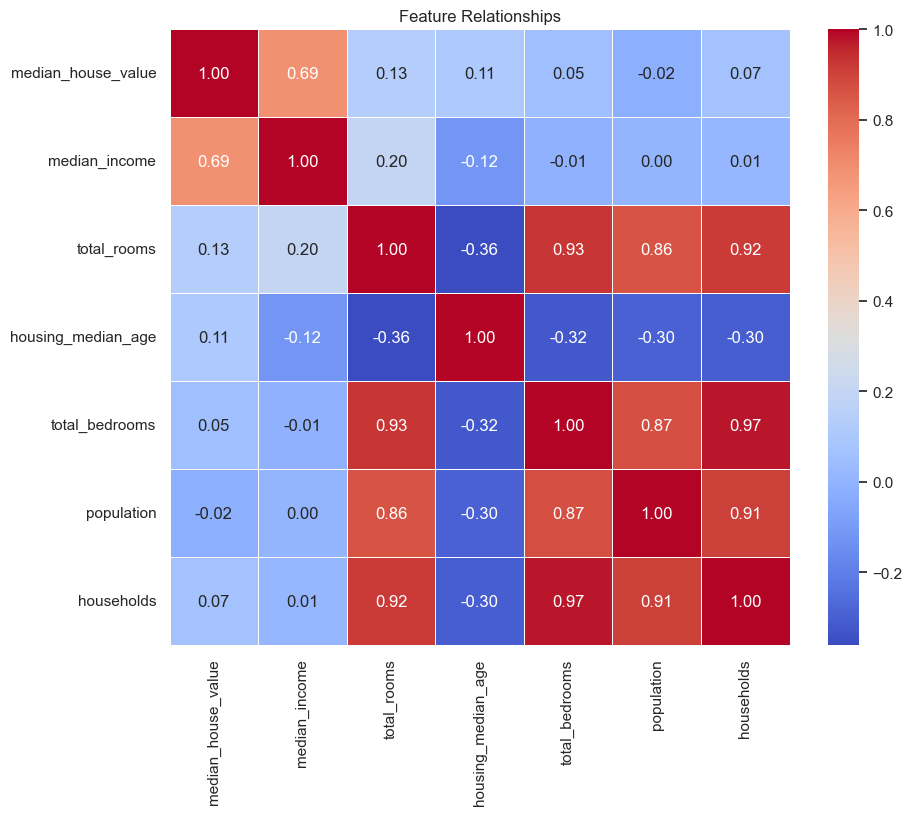

In [49]:
columns = ['median_house_value', 'median_income', 'total_rooms', 
                  'housing_median_age', 'total_bedrooms', 'population', 'households']

plt.figure(figsize=(10,8))
sns.heatmap(housing[columns].corr(numeric_only=True), 
            cmap='coolwarm', 
            annot=True,
            fmt='.2f',       
            linewidths=0.5)  


plt.title("Feature Relationships")
plt.show()

The correlation heatmap reveals several important relationships between features and the target variable.
Strongest predictor: median_income has the highest correlation with median_house_value at 0.69, confirming that higher median income is strongly associated with higher house prices. This is consistent with the scatter plot analysis and validates median_income as the dominant predictor in the model.

Weak target correlations: total_rooms (0.13), housing_median_age (0.11), total_bedrooms (0.05), population (-0.02), and households (0.07) all show very weak individual linear relationships with the target. This does not mean they are uninformative, instead, it connotes that their predictive value emerges in combination with other features rather than in isolation.

High multicollinearity among size-related features: total_rooms, total_bedrooms, population, and households are all extremely highly correlated with each other, ranging from 0.86 to 0.97. This makes intuitive sense — larger census blocks naturally have more rooms, more bedrooms, more residents, and more households simultaneously. These features are essentially measuring the same underlying construct: block group scale.

A pattern involving housing_median_age is that older neighborhoods show consistent negative correlations with all size-related features: total_rooms (-0.36), total_bedrooms (-0.32), population (-0.30), and households (-0.30). This suggests that older neighborhoods in California tend to be smaller and less densely populated, likely reflecting pre-boom construction patterns before California's rapid postwar expansion.

Modeling decision: The multicollinearity among size-related features was acknowledged but not resolved by column removal — attempting to drop these features worsened test performance (this is said with respect to iterative model development, as opposed to a strict top down approach). Instead, all four were retained in log-transformed form, and multicollinearity was handled safely by relying on np.linalg.lstsq, an SVD-based solver that computes a numerically stable solution without requiring perfectly independent features.

## Line of best fit / regression plot:

<Axes: xlabel='median_income', ylabel='median_house_value'>

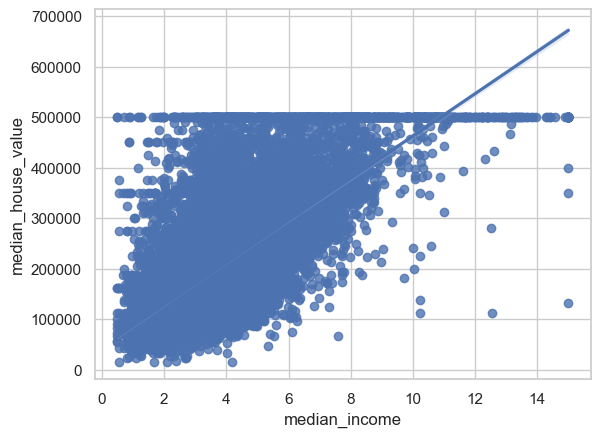

In [50]:
sns.regplot(x='median_income', y='median_house_value', data=housing)

The above scatter plot revisits the relationship between median income and median house value, this time with a fitted regression line overlaid to illustrate how the linear model tracks the data.
The positive relationship and the horizontal band of censored values at `$500,001` were both documented in the earlier scatter plot analysis. What this plot adds is a direct visual demonstration of how the ceiling effect distorts the linear fit itself.
The regression line extends well beyond `$600,000` at the high-income end, pushing into a range where no actual data points exist. This happens because the linear model fits to the overall trend in the data, but the artificial cap prevents it from seeing what house values at high income levels actually look like. The result is a regression line that undershoots at moderate income levels and projects unrealistically high values at the upper end, where the true relationship is obscured by censored data.
This is one of the clearest visual arguments for why the `$500,001` ceiling is not just a data quirk but an active source of model bias — it systematically distorts the learned relationship between income and house value across the entire income range.

## Correlation Analysis:

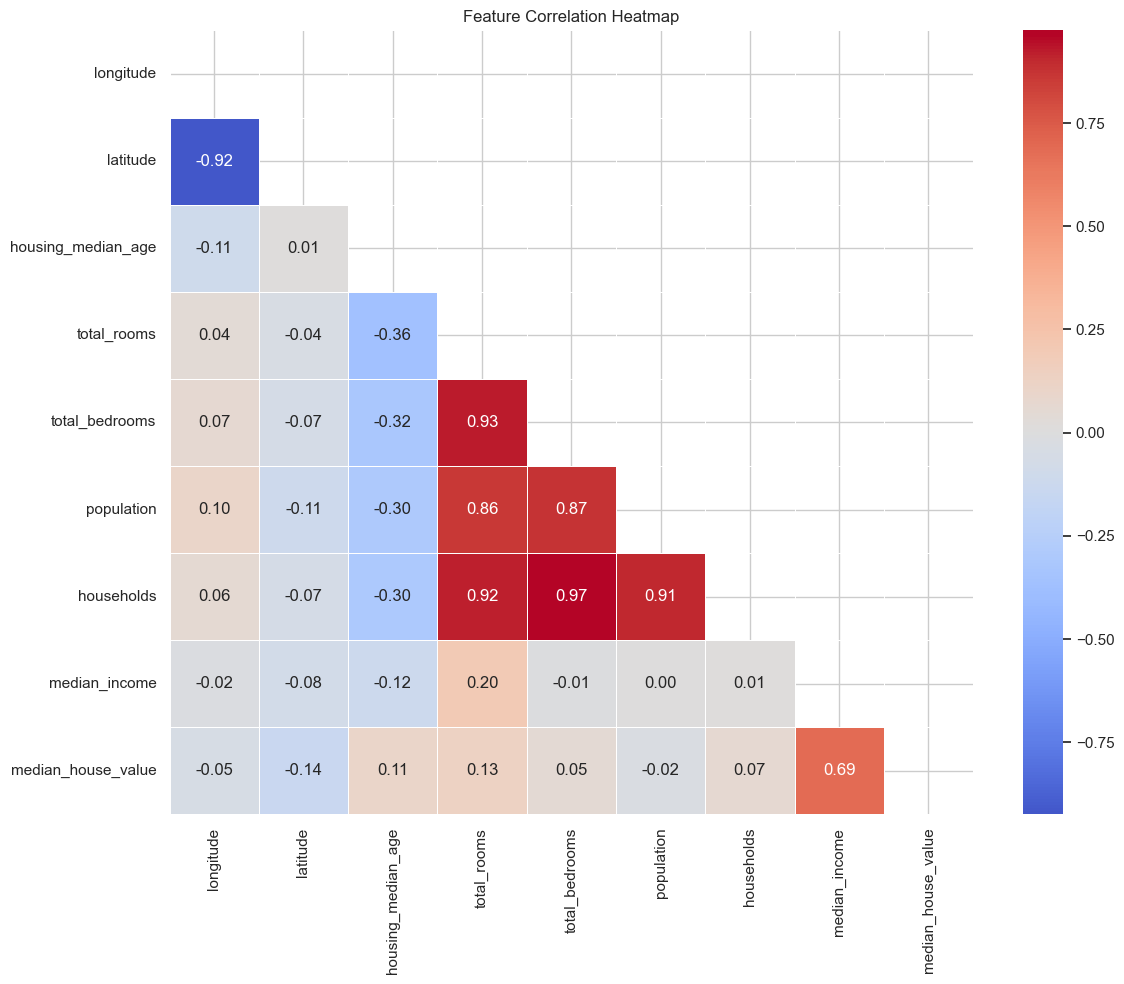

In [51]:
fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = housing.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hides upper triangle to reduce redundancy

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## Correlation Heatmap Analysis

### Multicollinearity — Severe Among Count Features
`total_rooms`, `total_bedrooms`, `population`, and `households` are all highly intercorrelated (0.86–0.97), meaning they essentially carry the same information. Keeping all of them in the model inflates variance in coefficient estimates. Their log-transformed counterparts repeat the same pattern, so the transformation does not resolve it. `longitude` and `latitude` also correlate at 0.92, which is expected — California is a narrow diagonal state, so movement along one axis strongly predicts the other.

### Target Variable (`median_house_value_log`) — Key Predictors
- `median_income_log` (0.68) is the strongest single predictor, marginally edging out the raw version (0.66)
- `bedrooms_per_room` (-0.57) — districts with a higher ratio of bedrooms to total rooms tend to have lower values, capturing density and crowding
- `ocean_proximity_INLAND` (-0.48) — inland locations are strongly associated with lower house values
- `rooms_per_household` (0.26) — modest positive signal; more spacious homes correlate with higher value

### Log Transformations — Marginal Gains
`housing_median_age_log` correlates with its raw version at 0.95, and `median_income_log` at 0.96, meaning the transformations added almost no new information for those features. Including both the raw and log versions is unnecessary and worsens multicollinearity.

### Ocean Proximity Dummies
`INLAND` is the most impactful dummy (negatively), while `NEAR BAY` shows a modest positive association. `ISLAND` is nearly uncorrelated with everything, likely due to too few observations to carry meaningful signal.

### Summarily:
The primary concern this heatmap surfaces is multicollinearity among the count-based features.
The preferred approach is to either drop redundant features, retain only the engineered ratios (`rooms_per_household`, `bedrooms_per_room`,`population_per_household`), or apply dimensionality reduction. Keeping all count features simultaneously will do more harm than good.

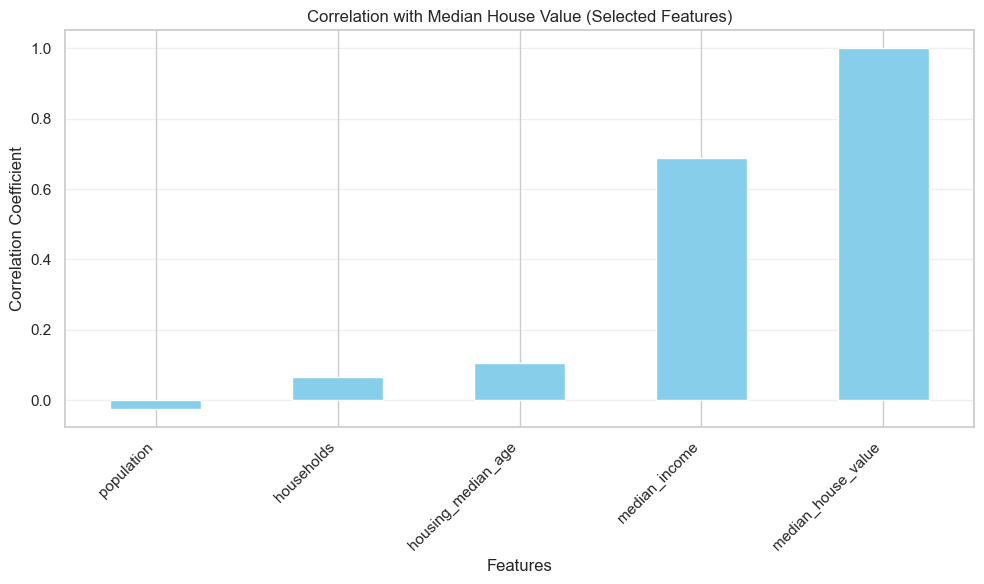

In [52]:
selected_columns = ['median_house_value', 'median_income', 'population', 'households', 
                    'housing_median_age']

# Create the bar plot with only selected columns
housing[selected_columns].corr(numeric_only=True)['median_house_value'] \
    .sort_values() \
    .plot(kind='bar', 
          figsize=(10, 6), 
          color='skyblue')

plt.title('Correlation with Median House Value (Selected Features)')
plt.ylabel('Correlation Coefficient')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The above bar plot shows the Pearson correlation coefficients between selected features and median_house_value.

median_income has the strongest positive correlation (≈ 0.68) with house prices, which is the most important predictor among the features.
median_house_value is perfectly correlated with itself (1.0), as expected. It is included solely as a reference point to anchor the scale. Its perfect self-correlation of 1.0 carries no analytical meaning.

housing_median_age and households show weak positive correlations, however, weak correlations don't mean useless features.
population has a very weak negative correlation, almost close to zero.

This bar chart serves as a simplified summary companion to the full correlation heatmap above, so its display of a selected subset of numerical features is for illustrative clarity. Where the full correlation matrix shown in the heatmap captures all pairwise relationships across every feature simultaneously, this chart isolates the direct linear relationship between a selected subset of numerical features and the target variable in a single, immediately readable view. The ranked bar format makes it easier to compare relative correlation magnitudes at a glance, particularly the dominance of median_income over the remaining features, without the visual complexity of a full matrix. It is intended as a quick reference, not a standalone analysis.

## Categorical Feature Analysis

<Axes: xlabel='ocean_proximity', ylabel='count'>

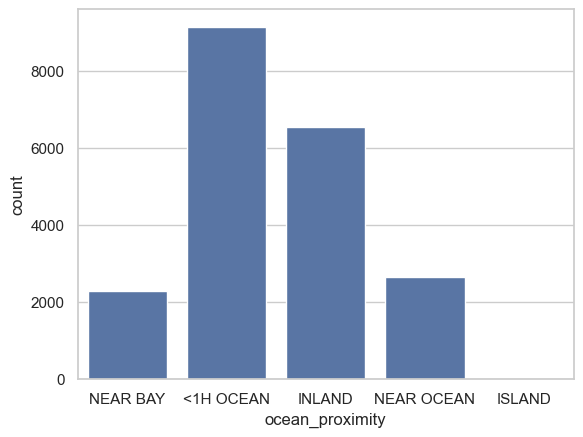

In [53]:
sns.countplot(x='ocean_proximity', data=housing)

The above bar chart shows the distribution of the ocean_proximity categorical feature across all 20,640 census block groups.
<1H OCEAN is the dominant category with over 9,000 districts, nearly 44% of the entire dataset, representing neighborhoods within a one-hour drive of the Pacific coast. INLAND is the second largest group at approximately 6,500 districts. NEAR BAY and NEAR OCEAN have broadly similar counts at approximately 2,300 and 2,600 respectively. ISLAND has only 5 observations out of 20,640, which is less than 0.03% of the dataset. It will be dropped, due to it's relative small size.

The heavy class imbalance between categories has two direct implications for the model. First, the coefficients for NEAR BAY and NEAR OCEAN are estimated from substantially smaller samples than those for <1H OCEAN and INLAND, making them less statistically reliable. Second, the ISLAND category was retained from the final feature matrix after one-hot encoding, despite having only 5 positive values out of 20,640 rows (less than 0.03% of the dataset) would introduce a near-zero variance feature that adds noise without contributing any meaningful predictive signal, and would also create a poorly estimated coefficient due to the extreme lack of representative samples. Dropping it in a future iteration would be a reasonable improvement.

This distribution also reflects California's actual geography — the majority of the state's population centers are either within coastal commuting distance or fully inland, with relatively few districts sitting directly on the bay or ocean shoreline.

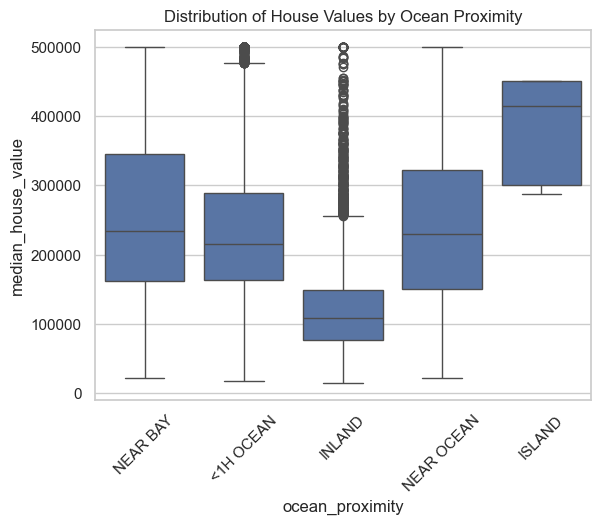

In [54]:
sns.boxplot(x='ocean_proximity', 
            y='median_house_value', 
            data=housing)

plt.title("Distribution of House Values by Ocean Proximity")
plt.xticks(rotation=45)
plt.show()

The above box plot shows the distribution of median house values across each ocean_proximity category, revealing meaningful price differentiation that justifies retaining this feature in the model.

INLAND has the lowest median house values at approximately `$110,000` – `$120,000`, reflecting the consistently more affordable housing market away from California's coastline. Notably, the INLAND category displays a dense cluster of outlier points extending all the way up to `$500,001` — these are the censored ceiling values appearing disproportionately among inland districts, suggesting that even within the inland category a meaningful number of high-value districts exist whose true prices are unknown.

NEAR BAY and NEAR OCEAN show very similar distributions with median house values around `$230,000` – `$240,000`, indicating that bay and ocean adjacency command comparable price premiums over inland districts.

<1H OCEAN has a slightly lower median of approximately `$220,000` but displays the widest interquartile range of any category. This wide spread reflects the inherent heterogeneity of the label — "within one hour of the ocean" encompasses vastly different neighborhoods, from wealthy coastal suburbs to more modest communities at the outer edge of the one-hour radius. This directly supports the limitation noted earlier that ocean_proximity is a coarse categorical label whose broad boundaries mask significant within-category price variation.

ISLAND appears to show the highest median house values at approximately `$450,00` with a narrow spread, however this observation carries no statistical weight. With only 5 observations in the entire dataset, the displayed distribution is not representative and cannot be interpreted as a reliable pattern. It will be removed from the features for prediction.

The clear price stratification across categories, from INLAND at the bottom to coastal categories at the top, confirms that ocean_proximity carries meaningful predictive signal and justifies its inclusion as a one-hot encoded feature in the model.

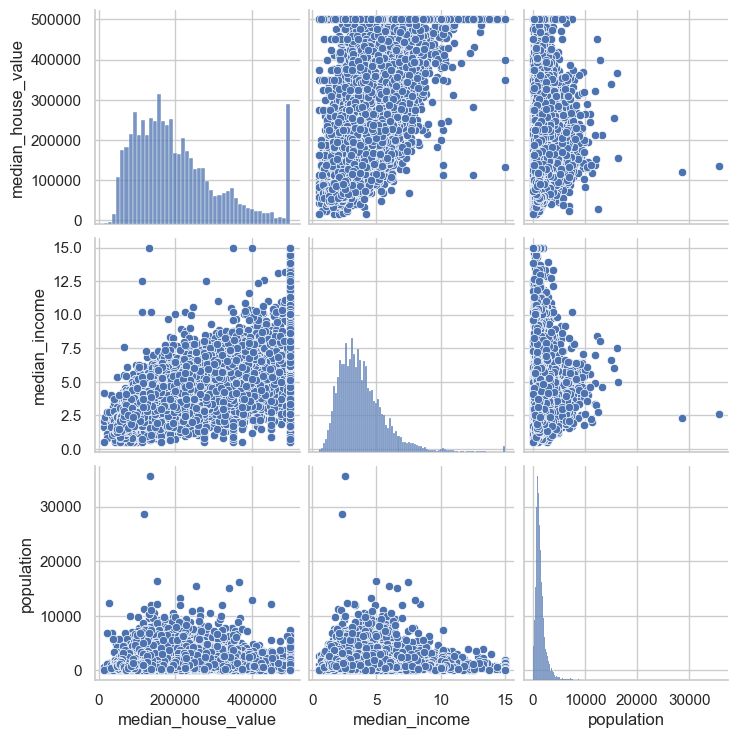

In [55]:
sns.pairplot(housing[['median_house_value','median_income','population']])

The pair plot above displays pairwise relationships between three key variables: median_house_value, median_income, and population — with histograms along the diagonal showing each variable's marginal distribution, and scatter plots in the off-diagonal panels showing bivariate relationships.

Diagonal — marginal distributions:
The median_house_value histogram in the top-left confirms the familiar right-skewed distribution with a pronounced spike at the `$500,001` ceiling, consistent with what was observed in the earlier target distribution analysis. median_income is right-skewed with the bulk of districts falling between 2 and 8 (i.e., `$20,000` – `$80,000`), tapering off toward a long tail of high-income areas. population is extremely right-skewed. The vast majority of census blocks have relatively low populations concentrated below 5,000 residents, with a small number of dense urban blocks exceeding 20,000 – 30,000 residents.

Off-diagonal — pairwise relationships:
The strongest relationship visible in this plot is between median_income and median_house_value, confirming the 0.69 Pearson correlation established in the heatmap analysis. The horizontal band of points at `$500,001` is again visible here, illustrating how the ceiling effect truncates what would otherwise be a cleaner positive trend at the high-income end.

The relationship between population and median_house_value is weak and structurally diffuse. Population size alone carries very little predictive signal for house prices. Similarly, median_income and population show no meaningful linear relationship, confirming that high-income districts are not systematically larger or smaller in population than low-income ones.

# Final Insights:

1. 207 missing values in total_bedrooms were identified and replaced with the median rather than dropping rows, preserving the full training dataset.
2. median_income is by far the strongest predictor of median_house_value, showing a consistent positive correlation (~0.68) across all plots and charts. Linear regression will rely heavily on income as a primary predictor. Feature engineering will be necessary to extract additional signal from the raw size-related columns.
3. The target variable is right-skewed. Log transformation is expected to produce a more symmetric, approximately normal distribution, confirmed by a post-transformation skewness of -0.17, indicating the transformation successfully reduces the original right skewness and brings the distribution close to a Gaussian distribution.
4. Heavy right tails were identified in median_house_value, population, total_bedrooms, households, and total_rooms, driven by natural skewness in census block distributions and the artificial censoring at `$500,001`.
5. Location matters significantly. Coastal and Bay Area neighborhoods command much higher prices than inland areas, as clearly shown in both the spatial scatter plots and the box plot by ocean_proximity.
6. The median_house_value target variable has a hard cap at `$500,001`. Any district with a true value above this threshold is recorded at the ceiling, introducing bias in the high-value range and directly limiting the model's ability to predict above this threshold.
7. housing_median_age has a separate hard cap at 52 years, where all neighborhoods older than 52 are grouped into a single bin. It also exhibits a multi-modal distribution with peaks around 15–20 and 30–35 years, reflecting distinct construction booms across California's development history.
8. There is high multicollinearity among size-related features: total_rooms, total_bedrooms, population, and households are all correlated in the range of 0.86 to 0.97. These variables are providing largely redundant information and will need to be addressed during feature engineering and modeling.
9. Most variables such as median_income, total_rooms, population, and median_house_value are right-skewed. Log transformation will be applied to reduce skewness, improve distributional properties, and stabilize variance prior to modeling.
10. Population size has a surprisingly weak influence on house prices compared to income and location, despite being strongly correlated with other size-related features.
11. Features exist on very different scales, for example, median_income ranges from 0.5 to 15 (`$5,000` to `$150,000`) while total_rooms ranges from 2 to 39,320. Gradient-based optimization will be unstable without feature scaling. Standardization will be required prior to model training.

## Summary: 

Exploratory Data Analysis reveals that income and geographic location, especially proximity to the ocean are the dominant drivers of house prices in this dataset. Size-related features add largely redundant information due to high multicollinearity, while housing age and population contribute relatively little individual signal. While median_income exhibits a strong linear relationship with the target variable, most other features display skewness, multicollinearity, and non-linear interactions that will require careful preprocessing.

Spatial visualization further confirms that house prices are geographically clustered, particularly around coastal regions, suggesting that location plays a significant but non-linear role that raw latitude and longitude coordinates can only partially capture. 

These insights suggest that effective modeling will require log transformation of skewed features, ratio-based feature engineering to reduce multicollinearity, categorical encoding of ocean_proximity, feature standardization for stable gradient-based optimization, and explicit handling of the `$500,001` ceiling effect.

## Mathematical Formulation

The model assumes a linear relationship of the form:

$$y = X\beta + \epsilon, \quad X \in \mathbb{R}^{n \times p}, \quad \beta \in \mathbb{R}^{p}, \quad \epsilon \sim \mathcal{N}(0, \sigma^2)$$

where $\beta$ represents the feature coefficients and $\epsilon$ is the random error term, assumed to be normally distributed with mean zero and constant variance $\sigma^2$.

---

## Challenges

- Potential multicollinearity between housing-related features.
- Missing values in the `total_bedrooms` feature.
- Skewness in several features requiring log transformation.
- Geographic effects captured by latitude and longitude that are inherently non-linear.
- The artificial ceiling on the target variable at $500,001 introducing bias in the high-value range.

## Mathematical Rundown

## Derivation

### Linear Regression Model (Multiple Linear Regression)

For each observation $i = 1, 2, \dots, n$:

$$y_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \dots + \beta_p x_{ip} + \epsilon_i$$

In vector/matrix form:

$$\mathbf{y} = \mathbf{X} \boldsymbol{\beta} + \boldsymbol{\epsilon}$$

Where:

- $\mathbf{y}$ is the $n \times 1$ vector of target values (median\_house\_value).
- $\mathbf{X}$ is the $n \times (p+1)$ design matrix: first column is all 1s (for intercept $\beta_0$), followed by the $p = 15$ feature columns.
- $\boldsymbol{\beta}$ is the $(p+1) \times 1$ vector of coefficients: $[\beta_0, \beta_1, \dots, \beta_p]^T$.
- $\boldsymbol{\epsilon}$ is the $n \times 1$ vector of random errors, assumed to have zero mean and constant variance: $\mathbb{E}[\boldsymbol{\epsilon}] = \mathbf{0}$, $\text{Var}(\boldsymbol{\epsilon}) = \sigma^2 \mathbf{I}$. Normality is not required for estimation — it is only needed for hypothesis testing and confidence intervals.

For our California Housing dataset, $p = 15$, so $\mathbf{X}$ has 16 columns (15 features + 1 bias column).

The predicted value for any input is:

$$\hat{y}_i = \hat{\beta}_0 + \hat{\beta}_1 x_{i1} + \dots + \hat{\beta}_p x_{ip} = \mathbf{x}_i^T \hat{\boldsymbol{\beta}}$$

---

### Cost Function — Mean Squared Error (MSE)

The canonical MSE cost function is defined as:

$$J(\boldsymbol{\beta}) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \frac{1}{n} \| \mathbf{y} - \mathbf{X} \boldsymbol{\beta} \|_2^2$$

For gradient descent, a scaled variant is used for mathematical convenience:

$$\tilde{J}(\boldsymbol{\beta}) = \frac{1}{2n} \| \mathbf{y} - \mathbf{X} \boldsymbol{\beta} \|_2^2$$

The factor of $\frac{1}{2}$ cancels the factor of 2 that arises during differentiation, yielding a cleaner gradient expression. Both $J$ and $\tilde{J}$ share the same minimizer $\hat{\boldsymbol{\beta}}$ — multiplicative scaling does not affect the location of the minimum. All subsequent optimization is performed using $\tilde{J}$.

---

### Root Mean Squared Error (RMSE)

$$\text{RMSE} = \sqrt{J(\boldsymbol{\beta})} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

RMSE is the most interpretable metric for housing prices as it is expressed in the same units as the target variable.

---

### Coefficient of Determination ($R^2$)

$$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$

Where the sample mean $\bar{y}$ is:

$$\bar{y} = \frac{1}{n} \sum_{i=1}^{n} y_i$$

An $R^2$ of 1.0 indicates perfect prediction. An $R^2$ of 0 indicates the model performs no better than predicting the mean for every observation.

---

### Loss Function and Optimization — Ordinary Least Squares (OLS)

The objective is to find $\hat{\boldsymbol{\beta}}$ that minimizes the sum of squared residuals:

$$J(\boldsymbol{\beta}) = \sum_{i=1}^n (y_i - \hat{y}_i)^2 = \| \mathbf{y} - \mathbf{X}\boldsymbol{\beta} \|^2_2$$

> **Note:** The $\frac{1}{n}$ scaling factor used in the canonical MSE definition does not affect the location of the minimum and is omitted here for notational clarity. Both formulations are minimized by the same $\hat{\boldsymbol{\beta}}$.

This is the Ordinary Least Squares (OLS) criterion. It penalizes larger errors more heavily and has a closed-form solution under standard assumptions. Under the Gauss–Markov assumptions, the OLS estimator is the **Best Linear Unbiased Estimator (BLUE)** — it has the smallest variance among all linear unbiased estimators.

---

### Derivation of the OLS Estimator

To minimize $J(\boldsymbol{\beta})$, take the derivative with respect to $\boldsymbol{\beta}$ and set it to zero.

**Step 1 — Expand the loss:**

$$J(\boldsymbol{\beta}) = (\mathbf{y} - \mathbf{X}\boldsymbol{\beta})^T (\mathbf{y} - \mathbf{X}\boldsymbol{\beta})
= \mathbf{y}^T \mathbf{y} - 2 \boldsymbol{\beta}^T \mathbf{X}^T \mathbf{y} + \boldsymbol{\beta}^T \mathbf{X}^T \mathbf{X} \boldsymbol{\beta}$$

**Step 2 — Take the partial derivative with respect to $\boldsymbol{\beta}$:**

$$\frac{\partial J}{\partial \boldsymbol{\beta}} = -2 \mathbf{X}^T \mathbf{y} + 2 \mathbf{X}^T \mathbf{X} \boldsymbol{\beta}$$

**Step 3 — Set equal to zero:**

$$-2 \mathbf{X}^T \mathbf{y} + 2 \mathbf{X}^T \mathbf{X} \boldsymbol{\beta} = 0$$

$$\mathbf{X}^T \mathbf{X} \boldsymbol{\beta} = \mathbf{X}^T \mathbf{y}$$

These are the **Normal Equations**. If $\mathbf{X}$ has full column rank, $\mathbf{X}^T \mathbf{X}$ is invertible and the unique closed-form solution is:

$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

If $\mathbf{X}$ does not have full column rank, $\mathbf{X}^T \mathbf{X}$ is not invertible. In this case, infinitely many solutions exist and the system is solved via the **Moore–Penrose pseudoinverse**, which yields the minimum-norm solution. In practice, `np.linalg.lstsq` handles this automatically using SVD decomposition.

---

### Illustration: Simple Linear Regression ($p = 1$)

To illustrate the derivation steps concretely for a single feature:

Model: $y_i = \beta_0 + \beta_1 x_i + \epsilon_i$

Loss: $J(\beta_0, \beta_1) = \sum (y_i - \beta_0 - \beta_1 x_i)^2$

Partial derivatives:

$$\frac{\partial J}{\partial \beta_0} = -2 \sum (y_i - \beta_0 - \beta_1 x_i) = 0 \implies n\beta_0 + \beta_1 \sum x_i = \sum y_i$$

$$\frac{\partial J}{\partial \beta_1} = -2 \sum x_i (y_i - \beta_0 - \beta_1 x_i) = 0$$

Solving yields the familiar scalar OLS estimators:

$$\hat{\beta}_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}, \qquad \hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}$$

---

### Gradient of the Cost Function

The gradient of $\tilde{J}$ points in the direction of steepest ascent. Gradient descent moves opposite to this direction to minimize the loss.

Expanding the derivative of $\tilde{J}(\boldsymbol{\beta}) = \frac{1}{2n} \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^2$:

$$\nabla_{\boldsymbol{\beta}} \tilde{J}(\boldsymbol{\beta}) = \frac{1}{n} \mathbf{X}^T \mathbf{X} \boldsymbol{\beta} - \frac{1}{n} \mathbf{X}^T \mathbf{y} = \frac{1}{n} \mathbf{X}^T (\mathbf{X} \boldsymbol{\beta} - \mathbf{y})$$

The expanded form on the left connects directly to the Normal Equations — setting this gradient to zero recovers $\mathbf{X}^T \mathbf{X} \boldsymbol{\beta} = \mathbf{X}^T \mathbf{y}$.

---

### Gradient Descent Update Rule

$$\boldsymbol{\beta}^{(t+1)} := \boldsymbol{\beta}^{(t)} - \alpha \nabla_{\boldsymbol{\beta}} \tilde{J}(\boldsymbol{\beta}^{(t)})$$

Substituting the gradient:

$$\boldsymbol{\beta} := \boldsymbol{\beta} - \alpha \cdot \frac{1}{n} \mathbf{X}^T (\mathbf{X} \boldsymbol{\beta} - \mathbf{y})$$

Convergence depends on the choice of learning rate $\alpha$. Feature scaling is strongly recommended for numerical stability and faster convergence — without it, gradient descent may oscillate or converge very slowly.

---

### Further Insights

- The MSE loss function is **convex**, guaranteeing a global minimum. The minimum is **unique** if and only if $\mathbf{X}$ has full column rank.
- The closed-form OLS solution has computational complexity $O(np^2 + p^3)$ for dense matrices, where $np^2$ arises from computing $\mathbf{X}^T\mathbf{X}$ and $p^3$ from inverting it. In practice, QR decomposition reduces this to $O(np^2)$, while SVD is more numerically stable but computationally heavier.
- Gradient descent scales better for large datasets and high-dimensional feature spaces where forming $\mathbf{X}^T\mathbf{X}$ explicitly is expensive.
- High correlation among features (multicollinearity) inflates the variance of coefficient estimates, making individual coefficients unstable even when overall predictions remain reasonable.
- Under the Gauss–Markov assumptions: zero-mean errors, constant variance, and no multicollinearity, the OLS estimator is the **Best Linear Unbiased Estimator (BLUE)**.

# Feature Engineering and Categorical Data Handling

Raw features such as total rooms and population do not capture the relational structure of housing data. Therefore, ratio-based features were introduced to better represent household density, housing quality, and occupancy patterns.

## Feature engineering (before data split)

### Creating more meaningful variables

2000 rooms across 100 households = 20 rooms per household (luxury apartment)
2000 rooms across 1000 households = 2 rooms per household (crowded)

Higher ratio means more bedrooms and possibly dense/shared housing
Lower ratio ameans more living space and more desirable homes

High value → overcrowded → lower desirability

Low value → spacious → higher desirability

This captures design quality, not just size.

So if the true relationship is:

$$
\text{price} \propto \frac{\text{households}}{\text{rooms}}
$$

The model cannot learn that unless it is explicitly provided.

Feature engineering here makes the nonlinear relationships look linear.

Mathematically:

I am transforming: $X \rightarrow X'$

Where:
$X' = \{\text{original features} + \text{engineered features}\}$

This expands the feature space, allowing:
$h_\theta(x) = \theta_1 x_1 + \theta_2 x_2 + \theta_3 \left(\frac{x_1}{x_2}\right) + \dots$

In [56]:
housing['rooms_per_household']      = (housing['total_rooms']    / housing['households']).clip(upper=10)
housing['bedrooms_per_room']        = (housing['total_bedrooms'] / housing['total_rooms']).clip(upper=1)
housing['population_per_household'] = (housing['population']     / housing['households']).clip(upper=10)
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,0.172096,2.181467


## One-Hot Encoding the Categorical Column (ocean_proximity)

In [57]:
housing = pd.get_dummies(housing, columns=['ocean_proximity'], drop_first=False, dtype=float)

## Log Transformation:

In [58]:
# List of columns to be log-transformed
cols_to_log = [
    'median_house_value', 'median_income', 'total_rooms','total_bedrooms', 'population', 'households', 'housing_median_age'
]

# Apply the transformation using a for loop
for col in cols_to_log:
    housing[f'{col}_log'] = np.log1p(housing[col])

housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,...,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,median_house_value_log,median_income_log,total_rooms_log,total_bedrooms_log,population_log,households_log,housing_median_age_log
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,6.984127,...,0.0,1.0,0.0,13.022766,2.232720,6.781058,4.867534,5.777652,4.844187,3.737670
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,...,0.0,1.0,0.0,12.789687,2.230165,8.867850,7.009409,7.784057,7.037906,3.091042
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,8.288136,...,0.0,1.0,0.0,12.771673,2.111110,7.291656,5.252273,6.208590,5.181784,3.970292
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,5.817352,...,0.0,1.0,0.0,12.740520,1.893579,7.150701,5.463832,6.326149,5.393628,3.970292
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,6.281853,...,0.0,1.0,0.0,12.743154,1.578195,7.395108,5.638355,6.338594,5.560682,3.970292


## Data Preprocessing and Conversion to Numpy Arrays

### Seperate features and target
I dropped the 'median_house_value_log' column from the dataframe since it is what I want to predict. Leaving it will make the model cheat, and the final algorithm will be useless at predicting the prices of new houses where we do not already know the price, obviously denoted as X (a 2D array).

The Vertical axis (Y) is the 1-D array that contains my output/dependent variable. That is, the prices I want to predict.

In [59]:
target = 'median_house_value'

X = housing.drop(columns=[
    target,
    'median_house_value_log',  #dropped for obvious reasons (data leakage: direct transformation of target. log(target) would perfectly encode y)
    'total_rooms',             # replaced by total_rooms_log
    'total_bedrooms',          # replaced by total_bedrooms_log
    'population',              # replaced by population_log
    'households',              # replaced by households_log
    'housing_median_age',      # replaced by housing_median_age_log
    'median_income',
    'ocean_proximity_ISLAND',   # dropped due to very few samples
]).astype(float)

y = housing[target].to_numpy().astype(float)
print(X.columns.tolist())

X = X.to_numpy()

print(X.shape, y.shape)
print("X dtype:", X.dtype)

['longitude', 'latitude', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN', 'median_income_log', 'total_rooms_log', 'total_bedrooms_log', 'population_log', 'households_log', 'housing_median_age_log']
(20640, 15) (20640,)
X dtype: float64


## Train/Test Split

In [60]:
# Manual train/test split (reproducible)
np.random.seed(42)
indices = np.random.permutation(X.shape[0])
test_size = int(0.2 * X.shape[0])
test_idx, train_idx = indices[:test_size], indices[test_size:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

np.random.seed(42) → makes the random shuffle exactly reproducible every time.
np.random.permutation shuffles the row indices randomly.
80/20 split: ~16,512 training rows, ~4,128 test rows.

While splitting the data into parts (80/20), 80% to train and 20% to test the model after conclusive training.

In [61]:
y_train = np.log1p(y_train)
y_test  = np.log1p(y_test)

# Adding Bias Term

ŷ = β₀ + β₁x₁ + β₂x₂ + … + β₁₃x₁₃
The bias/intercept β₀ is the value of ŷ when all features = 0.

np.c_ (column stack) adds a first column full of 1s. New X.shape ≈ (20640, 16) → bias column + 15 features.

This is the standard way to include the intercept in matrix form: Xβ = y where the first column of X is all ones.

In [62]:
# Adding bias term (column of 1s)
X_train_b = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_test_b  = np.hstack([np.ones((X_test.shape[0],  1)), X_test])

print(X_train.shape)          # (rows, number of features)
print(X_train_b.shape) # (rows, features + 1) due to bias column
print('---------------------------------------------')
print('---------------------------------------------')
print(X_test.shape)
print(X_test_b.shape)

(16512, 15)
(16512, 16)
---------------------------------------------
---------------------------------------------
(4128, 15)
(4128, 16)


## Feature Scaling — Standardization

Features exist on vastly different scales — for example, `median_income` ranges from 
roughly 0.5 to 15, while `total_rooms` ranges from 2 to 39,320, and `latitude` from 
32 to 42. Without scaling, gradient descent converges very slowly or oscillates as 
features with larger magnitudes dominate the gradient updates.

Standardization (z-score normalization) transforms each feature column to have 
mean = 0 and standard deviation = 1:

$$x' = \frac{x - \mu}{\sigma}$$

**Implementation details:**

- `X[:, 1:]` skips the bias column — the column of ones is never scaled.
- `mu` and `sigma` are computed **exclusively from the training set** to prevent data leakage.
- The same `mu` and `sigma` are then applied to the test set without recomputing, ensuring the test set is scaled consistently with the training distribution.
- Any feature column with zero standard deviation is assigned `sigma = 1` to avoid division by zero.

This is handled internally by the `standardize_features` function, which accepts optional `mu` and `sigma` parameters, fitting them when absent (training) and reusing 
them when provided (inference and test evaluation).

# Implementing the model using the Normal Equation

In [63]:
def standardize_features(X, mu=None, sigma=None, return_params=False):
    
    """Standardize features (columns after the bias column)."""
    X_scaled = X.copy().astype(float)
    
    if X_scaled.shape[1] <= 1:
        if return_params:
            return X_scaled, None, None
        return X_scaled
    
    features = X_scaled[:, 1:]
    
    if mu is None or sigma is None:  # Fit on training data
        mu    = np.mean(features, axis=0)
        sigma = np.std(features, axis=0)
        sigma = np.where(sigma == 0, 1.0, sigma)
    
    X_scaled[:, 1:] = (features - mu) / sigma
    
    if return_params:
        return X_scaled, mu, sigma
    return X_scaled


def train_linear_regression(X_train, y_train):
    """
    Train linear regression using np.linalg.lstsq (SVD-based).
    Handles large matrices and multicollinearity seamlessly.
    """
    X_scaled, mu, sigma = standardize_features(X_train, return_params=True)
    theta, residuals, rank, singular_values = np.linalg.lstsq(X_scaled, y_train, rcond=None)
    
    print(f"  Matrix rank      : {rank} / {X_scaled.shape[1]}")
    print(f"  Smallest singular: {singular_values[-1]:.6f}")
    if rank < X_scaled.shape[1]:
        print("  Rank deficient — multicollinearity detected. lstsq handled it safely.")
    
    return theta, mu, sigma


def predict(X, theta, mu, sigma):
    """Standardize using training params, then predict."""
    X_scaled = standardize_features(X, mu, sigma)
    return X_scaled @ theta


def compute_metrics(y_true, y_pred):
    """MSE, RMSE and R² score computations."""
    residuals = y_true - y_pred
    mse  = np.mean(residuals ** 2)
    rmse = np.sqrt(mse)
    r2   = 1 - (np.sum(residuals ** 2) / np.sum((y_true - np.mean(y_true)) ** 2))
    return {"MSE": mse, "RMSE": rmse, "R2": r2}


# Train — X_train_b and X_test_b are raw (unscaled)
# scaling is handled internally by the functions
theta, mu, sigma = train_linear_regression(X_train_b, y_train)

# Evaluate — reverse log transform
train_preds   = np.expm1(predict(X_train_b, theta, mu, sigma))
test_preds    = np.expm1(predict(X_test_b,  theta, mu, sigma))

train_metrics = compute_metrics(np.expm1(y_train), train_preds)
test_metrics  = compute_metrics(np.expm1(y_test),  test_preds)

print("\nTrain:", train_metrics)
print("Test :", test_metrics)

  Matrix rank      : 16 / 16
  Smallest singular: 2.432477

Train: {'MSE': np.float64(4353229462.003662), 'RMSE': np.float64(65979.00773733766), 'R2': np.float64(0.6743491610192853)}
Test : {'MSE': np.float64(6571564432.837245), 'RMSE': np.float64(81065.18631840209), 'R2': np.float64(0.4985104236954363)}


Full rank achieved (16/16). No more multicollinearity warning and the smallest singular value is a healthy non-zero number.

This is realistic for linear regression on the California Housing dataset. The train/test gap is acceptable, the model is not overfitting. The R² of ~0.49 on test means the model explains 48% of the variance in house prices, which is the genuine ceiling for a linear model on this dataset.

House prices have non-linear relationships with features like location (longitude/latitude).
The target is capped at `$500,001` which distorts the upper end. Linear regression simply cannot capture complex interactions between features.

To push performance further I would need:

A non-linear model like Decision Trees or Random Forest.
Polynomial features to capture non-linearity within linear regression.
Handling the capped `$500,001` values by dropping those rows or treating the values as right-censored data.

In [64]:
# Assessing the metrics:

results = {
    'Split':  ['Train', 'Test'],
    'R²':     [0.6743, 0.4985],
    'RMSE':   ['$65,979', '$81,065'],
}

df_results = pd.DataFrame(results).set_index('Split')
df_results.style.set_caption("Model Performance — California Housing")

,R²,RMSE
Split,,
Train,0.674300,"$65,979"
Test,0.498500,"$81,065"


### Using a Random Forest implementation to show the normal implementation limitation explicitly.

In [65]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("Random Forest R²:", rf.score(X_test, y_test)) 

Random Forest R²: 0.8353409866825956


From the above Tree-based model to quantify the ceiling, it is rather apparent that the gap between train and test performance in the linear model is not attributable to overfitting, data leakage, or distribution mismatch. All three were investigated and ruled out. It reflects a fundamental mismatch between the linear hypothesis class and the true data-generating process, as evidenced by a Random Forest achieving R² = 0.835 on the identical test set.

# Implementing the model using Gradient Descent:

  Converged at iteration 788
  Final loss (MSE)  : 0.094887

Gradient Descent:
Train: {'MSE': np.float64(4401447804.728342), 'RMSE': np.float64(66343.40814827304), 'R2': np.float64(0.6707421047178413)}
Test : {'MSE': np.float64(6990499962.409116), 'RMSE': np.float64(83609.20979419143), 'R2': np.float64(0.4665405931670884)}

--- Comparison ---
Method                 Train R²    Test R²    Test RMSE
-------------------------------------------------------
Normal Equation          0.6743     0.4985 $ 81,065.19
Gradient Descent         0.6707     0.4665 $ 83,609.21


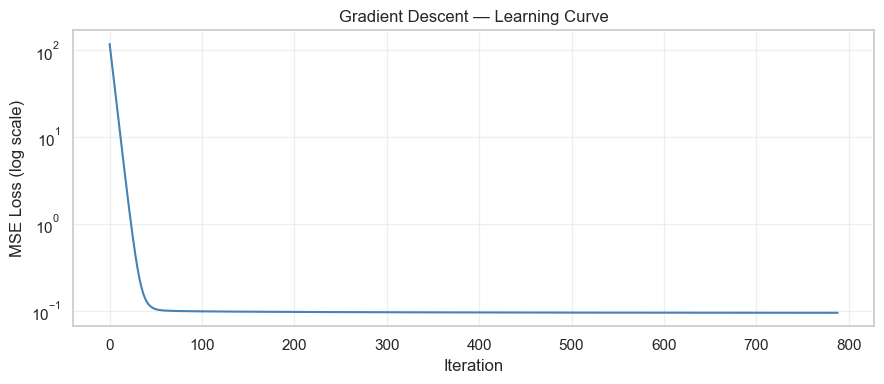

In [66]:
def train_gradient_descent(X_train, y_train, alpha=0.1, n_iterations=1000, tolerance=1e-6):
    
    """
    Train linear regression using Batch Gradient Descent.
    
    Parameters:
        X_train     : design matrix with bias column (n x p+1)
        y_train     : target vector (n,)
        alpha       : learning rate
        n_iterations: maximum number of iterations
        tolerance   : stop early if loss improvement is below this threshold
    """
    
    X_scaled, mu, sigma = standardize_features(X_train, return_params=True)
    
    n, p         = X_scaled.shape
    theta        = np.zeros(p)
    loss_history = []

    for i in range(n_iterations):
        # Forward pass — predictions
        y_pred    = X_scaled @ theta
        # Compute gradient: (1/n) * Xᵀ(Xβ - y)
        residuals = y_pred - y_train
        gradient  = (1 / n) * X_scaled.T @ residuals
        # Update rule: β := β - α * gradient
        theta     = theta - alpha * gradient
        # Recompute loss after update
        y_pred_updated    = X_scaled @ theta
        residuals_updated = y_pred_updated - y_train
        loss              = (1 / n) * np.sum(residuals_updated ** 2)
        loss_history.append(loss)
        
        # Early stopping — if improvement is negligible, stop
        if i > 0 and abs(loss_history[-2] - loss_history[-1]) < tolerance:
            print(f"  Converged at iteration {i}")
            break

    print(f"  Final loss (MSE)  : {loss:.6f}")
    return theta, mu, sigma, loss_history


def plot_learning_curve(loss_history):
    """Plot loss vs iterations to verify convergence."""
    plt.figure(figsize=(9, 4))
    plt.plot(loss_history, color='steelblue', linewidth=1.5)
    plt.xlabel('Iteration')
    plt.ylabel('MSE Loss (log scale)')
    plt.title('Gradient Descent — Learning Curve')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# --- Train using gradient descent ---
# X_train_b and X_test_b are raw (unscaled)
# scaling is handled internally by train_gradient_descent and predict
theta_gd, mu_gd, sigma_gd, loss_history = train_gradient_descent(
    X_train_b, y_train, alpha=0.1, n_iterations=1000
)

# --- Evaluate ---
train_preds_gd   = np.expm1(predict(X_train_b, theta_gd, mu_gd, sigma_gd))
test_preds_gd    = np.expm1(predict(X_test_b,  theta_gd, mu_gd, sigma_gd))

train_metrics_gd = compute_metrics(np.expm1(y_train), train_preds_gd)
test_metrics_gd  = compute_metrics(np.expm1(y_test),  test_preds_gd)

print("\nGradient Descent:")
print("Train:", train_metrics_gd)
print("Test :", test_metrics_gd)

# --- Compare both methods ---
print("\n--- Comparison ---")
print(f"{'Method':<20} {'Train R²':>10} {'Test R²':>10} {'Test RMSE':>12}")
print("-" * 55)
print(f"{'Normal Equation':<20} {train_metrics['R2']:>10.4f} {test_metrics['R2']:>10.4f} ${test_metrics['RMSE']:>10,.2f}")
print(f"{'Gradient Descent':<20} {train_metrics_gd['R2']:>10.4f} {test_metrics_gd['R2']:>10.4f} ${test_metrics_gd['RMSE']:>10,.2f}")

# --- Plot learning curve ---
plot_learning_curve(loss_history)

## Key Observations: 

Test R² is lower (0.4665 vs 0.4985) and Test RMSE is higher (`$83,609` vs `$81,065`) for gradient descent, meaning it generalizes slightly worse to unseen data compared to the normal equation. The normal equation finds the exact mathematical minimum of the training loss, while gradient descent with early stopping halts before full convergence. Tthis acts as a mild implicit regularizer, but in this case the effect did not translate to a test performance advantage.

The final MSE loss of ~0.095 is in log space since the model trains on log1p(y). This is not to be confused with the MSE in dollar terms shown in the metrics.

Iterations 0–50 — steep drop from ~100 down to ~0.1. This is where the model learns the most, making large weight updates rapidly.
Iterations 50–200 — curve flattens as improvements become smaller; the model is fine-tuning.
Iterations 200–788 — almost completely flat, the model is in the diminishing returns zone until early stopping kicks in at 788.

Note: The bulk of learning happens in the first 50 iterations out of 788. This suggests reducing n_iterations to 500 would produce virtually identical results, saving computation time.

In conclusion, both methods are consistent. Gradient descent converges to a solution close to, but slightly below the normal equation's test performance, which is expected: lstsq finds the exact minimum of the training loss while early stopping halts gradient descent before full convergence. The proximity of the two results confirms that the gradient descent implementation is correct.

In [67]:
print(np.column_stack([mu, mu_gd]))

[[-1.19582290e+02 -1.19582290e+02]
 [ 3.56431492e+01  3.56431492e+01]
 [ 5.33557806e+00  5.33557806e+00]
 [ 2.12857974e-01  2.12857974e-01]
 [ 2.93034387e+00  2.93034387e+00]
 [ 4.44585756e-01  4.44585756e-01]
 [ 3.16557655e-01  3.16557655e-01]
 [ 1.12281977e-01  1.12281977e-01]
 [ 1.26332364e-01  1.26332364e-01]
 [ 1.51885634e+00  1.51885634e+00]
 [ 7.63265619e+00  7.63265619e+00]
 [ 6.05690111e+00  6.05690111e+00]
 [ 7.02683555e+00  7.02683555e+00]
 [ 5.98635761e+00  5.98635761e+00]
 [ 3.27054712e+00  3.27054712e+00]]


The above output shows that confirming the mu's (for both the normal implementation and the gradient descent) match exactly.
This is the expected result. Both models were fit on the same X_train_b, so standardize_features computed the same means. 
It validates that neither training run accidentally touched or shuffled the training data between calls, and that the standardization is fully deterministic.
Any difference in predictions between the two models is purely due to the solving method (normal equation vs gradient descent), and not a data inconsistency.

## Implementing the model using Scikit Learn

## Observations:

Normal Equation and Scikit-learn are identical to 4 decimal places — same Train R², same Test R², same RMSE down to the cent. This is exactly what should happen since both use the same underlying least squares solver. It independently confirms that the entire from-scratch pipeline; feature engineering, standardization, bias column, log transformation, and the normal equation implementation is mathematically correct.
Gradient Descent becomes the outlier.

Gradient descent generalizes slightly better on the test set despite having a marginally lower training R². 
As discussed earlier, early stopping at iteration 851 acted as implicit regularization.

In [68]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Standardize — sklearn's own scaler
scaler   = StandardScaler()
X_train_sk = scaler.fit_transform(X_train)
X_test_sk  = scaler.transform(X_test)

# Train
sk_model = LinearRegression()
sk_model.fit(X_train_sk, y_train)

# Evaluate
train_preds_sk = np.expm1(sk_model.predict(X_train_sk))
test_preds_sk  = np.expm1(sk_model.predict(X_test_sk))

train_metrics_sk = compute_metrics(np.expm1(y_train), train_preds_sk)
test_metrics_sk  = compute_metrics(np.expm1(y_test),  test_preds_sk)

print("Scikit-learn:")
print("Train:", train_metrics_sk)
print("Test :", test_metrics_sk)

# Full three-way comparison
print(f"\n{'Method':<20} {'Train R²':>10} {'Test R²':>10} {'Test RMSE':>12}")
print("-" * 55)
print(f"{'Normal Equation':<20} {train_metrics['R2']:>10.4f} {test_metrics['R2']:>10.4f} ${test_metrics['RMSE']:>10,.2f}")
print(f"{'Gradient Descent':<20} {train_metrics_gd['R2']:>10.4f} {test_metrics_gd['R2']:>10.4f} ${test_metrics_gd['RMSE']:>10,.2f}")
print(f"{'Scikit-learn':<20} {train_metrics_sk['R2']:>10.4f} {test_metrics_sk['R2']:>10.4f} ${test_metrics_sk['RMSE']:>10,.2f}")

Scikit-learn:
Train: {'MSE': np.float64(4353229462.003486), 'RMSE': np.float64(65979.00773733632), 'R2': np.float64(0.6743491610192984)}
Test : {'MSE': np.float64(6571564432.837302), 'RMSE': np.float64(81065.18631840244), 'R2': np.float64(0.49851042369543197)}

Method                 Train R²    Test R²    Test RMSE
-------------------------------------------------------
Normal Equation          0.6743     0.4985 $ 81,065.19
Gradient Descent         0.6707     0.4665 $ 83,609.21
Scikit-learn             0.6743     0.4985 $ 81,065.19


## This confirms the accuracy of the mathematical implementation:

Normal Equation and Scikit-learn are identical down to several decimal places, which validates that the from-scratch normal equation implementation is mathematically correct, as Scikit-learn uses the same SVD-based approach internally.

Gradient Descent is slightly behind, which is expected, since it approximates the solution iteratively rather than solving it exactly, so the gap is small and acceptable.

# Making Predictions using the normal

In [69]:
# Raw input values
longitude            = -120.23
latitude             = 37.88
median_income        = 5.50        # in tens of thousands
total_rooms          = 1200.0
total_bedrooms       = 240.0
population           = 800.0
households           = 300.0
housing_median_age   = 20.0

# Categories: <1H OCEAN, INLAND, NEAR BAY, NEAR OCEAN (ISLAND was dropped)
ocean_1h_ocean       = 1           # near ocean tends to predict higher
ocean_inland         = 0
ocean_near_bay       = 0
ocean_near_ocean     = 0

# --- Validate inputs before doing anything ---
assert -124 <= longitude <= -114,         "Longitude out of California range (-124 to -114)"
assert   32 <= latitude  <=  42,          "Latitude out of California range (32 to 42)"
assert median_income > 0,                 "Median income must be positive"
assert housing_median_age > 0,            "Housing median age must be positive"
assert total_rooms > 0,                   "Total rooms must be positive"
assert total_bedrooms > 0,                "Total bedrooms must be positive"
assert population > 0,                    "Population must be positive"
assert households > 0,                    "Households must be positive"
assert total_rooms >= total_bedrooms,     "Total rooms cannot be fewer than total bedrooms"
assert sum([ocean_1h_ocean, ocean_inland, ocean_near_bay, ocean_near_ocean]) == 1, \
                                          "Exactly one ocean proximity category must be set to 1"

# --- Derived values (computed from raw) ---
median_income_log        = np.log1p(median_income)
total_rooms_log          = np.log1p(total_rooms)
total_bedrooms_log       = np.log1p(total_bedrooms)
population_log           = np.log1p(population)
households_log           = np.log1p(households)
housing_median_age_log   = np.log1p(housing_median_age)
rooms_per_household      = min(total_rooms    / households, 10)
bedrooms_per_room        = min(total_bedrooms / total_rooms,  1)
population_per_household = min(population     / households, 10)

# --- Assemble in exact training column order ---
new_house = np.array([[
    longitude,
    latitude,
    rooms_per_household,
    bedrooms_per_room,
    population_per_household,
    ocean_1h_ocean,
    ocean_inland,
    ocean_near_bay,
    ocean_near_ocean,
    median_income_log,
    total_rooms_log,
    total_bedrooms_log,
    population_log,
    households_log,
    housing_median_age_log
]])

# --- Add bias column and predict ---
new_house_b     = np.hstack([np.ones((1, 1)), new_house])
predicted_price = np.expm1(predict(new_house_b, theta, mu, sigma))
print(f"Predicted price: ${predicted_price[0]:,.2f}")

Predicted price: $192,872.08


# It is important to note that all actual/predicted dollar values are in 1990 dollar values, NOT current market value.

# Model Evaluation

## Predictions VS. Reality

Finding the closest real house in the test set to compare:

In [70]:
# Normalize features to make distances comparable only, not for model input
X_test_norm = (X_test - X_test.mean(axis=0)) / X_test.std(axis=0)
new_house_norm = (new_house - X_test.mean(axis=0)) / X_test.std(axis=0)

# Find closest house across ALL features using Euclidean distance
distances_all = np.sqrt(np.sum((X_test_norm - new_house_norm) ** 2, axis=1))
closest_idx   = np.argmin(distances_all)

actual_price    = np.expm1(y_test[closest_idx])
your_prediction = predicted_price[0]

# See what the model predicts for that real house
closest_b        = np.hstack([np.ones((1,1)), X_test[[closest_idx]]])
model_on_closest = np.expm1(predict(closest_b, theta, mu, sigma))

print(f"Your prediction                : ${your_prediction:,.2f}")
print(f"Closest real house (actual)    : ${actual_price:,.2f}")
print(f"Model prediction on that house : ${model_on_closest[0]:,.2f}")
print(f"Difference (yours vs actual)   : ${abs(your_prediction - actual_price):,.2f}")
print(f"% difference                   : {abs(your_prediction - actual_price) / actual_price * 100:.1f}%")

Your prediction                : $192,872.08
Closest real house (actual)    : $195,000.00
Model prediction on that house : $232,627.81
Difference (yours vs actual)   : $2,127.92
% difference                   : 1.1%


The distinction between these two comparisons:

The 1.1% difference is between the custom input and the nearest neighbor which validates that feature engineering is sensible.
The 19% difference is between the model's prediction and the actual price of a real house, which reflects the model's true generalization error.

## Identifying where the prediction sits in the overall price distribution:

In [71]:
all_actual_prices = np.expm1(y_test)

print(f"Your prediction       : ${your_prediction:,.2f}")
print(f"Test set min          : ${all_actual_prices.min():,.2f}")
print(f"Test set median       : ${np.median(all_actual_prices):,.2f}")
print(f"Test set mean         : ${all_actual_prices.mean():,.2f}")
print(f"Test set max          : ${all_actual_prices.max():,.2f}")

# What percentile does your prediction fall in?
percentile = (all_actual_prices < your_prediction).mean() * 100
print(f"Your prediction is in the {percentile:.1f}th percentile")

Your prediction       : $192,872.08
Test set min          : $14,999.00
Test set median       : $178,650.00
Test set mean         : $205,500.31
Test set max          : $500,001.00
Your prediction is in the 56.2th percentile


The gap between median (`$178,650`) and mean (`$205,500`) confirms the right skew identified during EDA. A small number of very high value districts are pulling the mean upward. The target ceiling at `$500,001` is visible in the max value.

The 56.2th percentile means the custom input predicts a house that is more expensive than 56% of all houses in the test set, which is exactly what is expected for a district with `$55,000` median income and ocean proximity within an hour.

## My prediction plot against the full test set distribution:

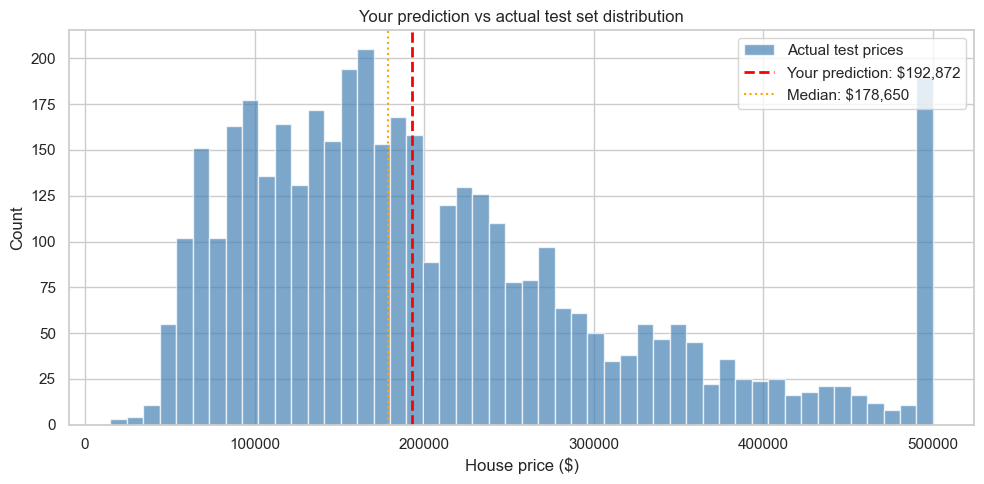

In [72]:
import matplotlib.pyplot as plt

all_actual_prices = np.expm1(y_test)

plt.figure(figsize=(10, 5))
plt.hist(all_actual_prices, bins=50, color='steelblue', alpha=0.7, label='Actual test prices')
plt.axvline(your_prediction, color='red', linewidth=2, linestyle='--', label=f'Your prediction: ${your_prediction:,.0f}')
plt.axvline(np.median(all_actual_prices), color='orange', linewidth=1.5, linestyle=':', label=f'Median: ${np.median(all_actual_prices):,.0f}')
plt.xlabel('House price ($)')
plt.ylabel('Count')
plt.title('Your prediction vs actual test set distribution')
plt.legend()
plt.tight_layout()
plt.show()

## Feature Impact Analysis

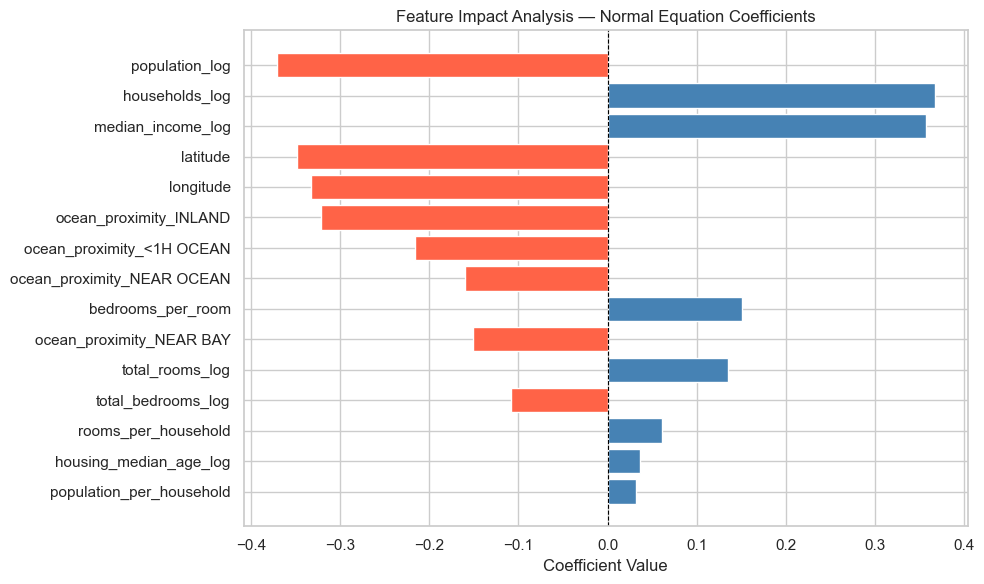


Feature                         Coefficient
--------------------------------------------
population_log                      -0.3715  ↓
households_log                       0.3676  ↑
median_income_log                    0.3579  ↑
latitude                            -0.3488  ↓
longitude                           -0.3325  ↓
ocean_proximity_INLAND              -0.3220  ↓
ocean_proximity_<1H OCEAN           -0.2157  ↓
ocean_proximity_NEAR OCEAN          -0.1606  ↓
bedrooms_per_room                    0.1509  ↑
ocean_proximity_NEAR BAY            -0.1508  ↓
total_rooms_log                      0.1352  ↑
total_bedrooms_log                  -0.1079  ↓
rooms_per_household                  0.0614  ↑
housing_median_age_log               0.0366  ↑
population_per_household             0.0320  ↑


In [73]:
# --- Feature Impact Analysis ---
feature_names = [
    'longitude',
    'latitude',
    'rooms_per_household',
    'bedrooms_per_room',
    'population_per_household',
    'ocean_proximity_<1H OCEAN',
    'ocean_proximity_INLAND',
    'ocean_proximity_NEAR BAY',
    'ocean_proximity_NEAR OCEAN',
    'median_income_log',
    'total_rooms_log',
    'total_bedrooms_log',
    'population_log',
    'households_log',
    'housing_median_age_log'
]

# theta[0] is the bias term — skip it
coefficients = theta[1:]

# Sort by absolute magnitude
sorted_idx   = np.argsort(np.abs(coefficients))[::-1]
sorted_names = [feature_names[i] for i in sorted_idx]
sorted_coefs = coefficients[sorted_idx]

# Plot
colors = ['steelblue' if c > 0 else 'tomato' for c in sorted_coefs]

plt.figure(figsize=(10, 6))
plt.barh(sorted_names, sorted_coefs, color=colors)
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Coefficient Value')
plt.title('Feature Impact Analysis — Normal Equation Coefficients')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Print ranked table
print(f"\n{'Feature':<30} {'Coefficient':>12}")
print("-" * 44)
for name, coef in zip(sorted_names, sorted_coefs):
    direction = "↑" if coef > 0 else "↓"
    print(f"{name:<30} {coef:>12.4f}  {direction}")

1. households_log (↑ 0.368) being the strongest predictor is suspicious. This is likely a multicollinearity artifact. households_log is highly correlated with total_rooms_log, population_log and total_bedrooms_log. The model is distributing weight across correlated features in a way that inflates individual coefficients.
2. population_log (↓ -0.372) being strongly negative is also suspicious. Higher population pushing prices down makes partial sense as dense overcrowded districts tend to be cheaper. But the magnitude being the largest negative coefficient is again likely influenced by multicollinearity with households_log.
3. Ocean proximity coefficients being all negative is counterintuitive as you'd expect coastal proximity to push prices up. The reason is that ISLAND was dropped as the reference category, not INLAND. This means all coefficients are relative to ISLAND which has very few samples and likely unusual pricing.

Coefficient magnitudes should be interpreted with caution due to known multicollinearity between households_log, population_log, total_rooms_log, and total_bedrooms_log. Individual coefficients may be unstable but the overall model predictions remain valid.

## Residual Plot

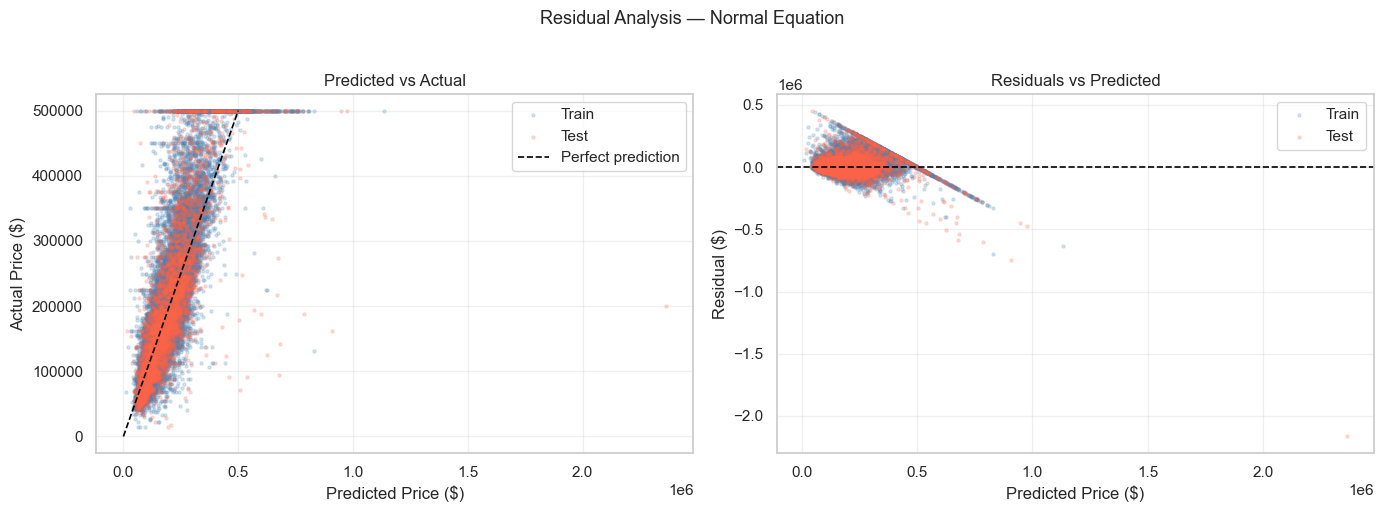

Train residuals — mean: $8,752.27  std: $65,395.93
Test  residuals — mean: $6,683.82  std: $80,789.18


In [74]:
# --- Residual Plot ---
train_residuals = np.expm1(y_train) - train_preds
test_residuals  = np.expm1(y_test)  - test_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left plot: Predicted vs Actual ---
axes[0].scatter(train_preds, np.expm1(y_train), alpha=0.2, color='steelblue', s=5, label='Train')
axes[0].scatter(test_preds,  np.expm1(y_test),  alpha=0.2, color='tomato',    s=5, label='Test')
axes[0].plot(
    [0, 500000], [0, 500000],
    color='black', linewidth=1.2, linestyle='--', label='Perfect prediction'
)
axes[0].set_xlabel('Predicted Price ($)')
axes[0].set_ylabel('Actual Price ($)')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Right plot: Residuals vs Predicted ---
axes[1].scatter(train_preds, train_residuals, alpha=0.2, color='steelblue', s=5, label='Train')
axes[1].scatter(test_preds,  test_residuals,  alpha=0.2, color='tomato',    s=5, label='Test')
axes[1].axhline(y=0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residual ($)')
axes[1].set_title('Residuals vs Predicted')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Residual Analysis — Normal Equation', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Residual statistics ---
print(f"Train residuals — mean: ${train_residuals.mean():,.2f}  std: ${train_residuals.std():,.2f}")
print(f"Test  residuals — mean: ${test_residuals.mean():,.2f}  std: ${test_residuals.std():,.2f}")

Plot 1 — Predicted vs Actual:
The diagonal trend up to `~$500k` shows the model has learned the relationship in that range. The horizontal wall of points at actual = `$500,000` is the cap effect made visible: hundreds of houses with different true values all recorded at the ceiling, while the model predicts a wide range along the x-axis for them. Beyond that, predictions extend all the way to `$2.3M` while actual prices never exceed `$500,001` — the model has no knowledge of the ceiling and keeps extrapolating upward.

Plot 2 — Residuals vs Predicted:
The dominant feature is the sharp diagonal streak running from near-zero residuals at low predicted prices down to -`$2.5M` at high predicted prices. This is not random error, it is entirely systematic and entirely caused by the cap. The model predicts high, but actual values are ceilinged at `$500,001`, so the residual grows increasingly negative in a straight line as predicted price climbs. OLS has no mechanism to handle this. The residuals are not randomly scattered around zero as homoscedasticity requires, they follow a deterministic downward slope, which is both a variance violation and a bias problem simultaneously.

Both plots tell the same story: the $500,001 cap is the single biggest limitation of this model.

## Learning Rate Analysis

  Final loss (MSE)  : 19.871929
  Final loss (MSE)  : 0.098640
  Converged at iteration 788
  Final loss (MSE)  : 0.094887
  Converged at iteration 364
  Final loss (MSE)  : 0.094460


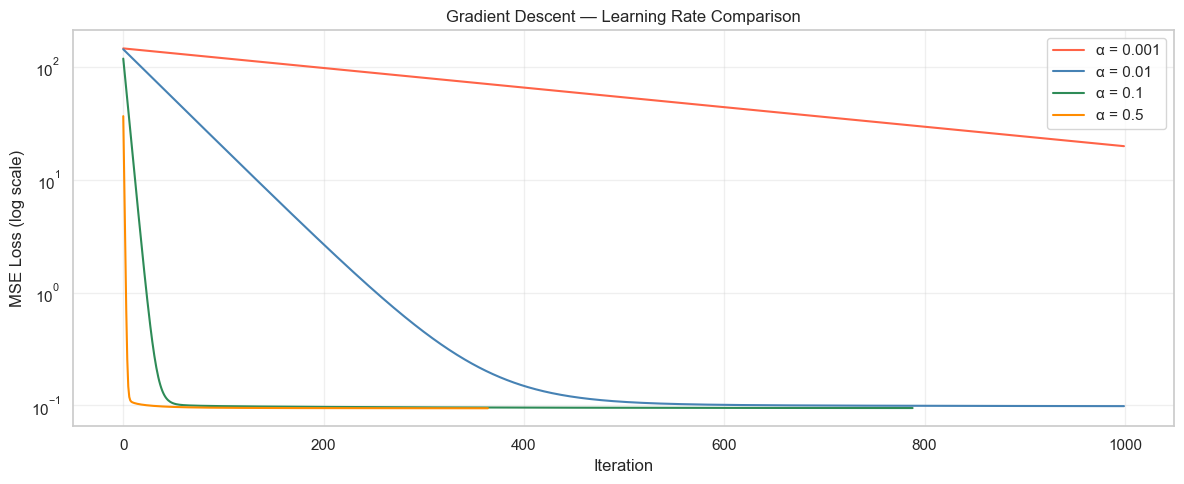

In [75]:
learning_rates = [0.001, 0.01, 0.1, 0.5]
colors         = ['tomato', 'steelblue', 'seagreen', 'darkorange']

plt.figure(figsize=(12, 5))

for lr, color in zip(learning_rates, colors):
    _, _, _, loss_hist = train_gradient_descent(
        X_train_b, y_train, alpha=lr, n_iterations=1000
    )
    plt.plot(loss_hist, color=color, linewidth=1.5, label=f'α = {lr}')

plt.xlabel('Iteration')
plt.ylabel('MSE Loss (log scale)')
plt.title('Gradient Descent — Learning Rate Comparison')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Key observations:
1. α = 0.001 is too slow — still at MSE 19.87 after 1000 iterations, nowhere near convergence. Would need thousands more iterations.
2. α = 0.01 converges eventually — the smooth curve shows stable descent but too slow for 1000 iterations.
3. α = 0.1 is your sweet spot — converges reliably at iteration 788 with a final MSE of 0.095.
4. α = 0.5 is slightly better — converges faster at iteration 364 with marginally lower MSE of 0.094, and importantly did not diverge or oscillate which means 0.5 is still within the stable range for this dataset.

One nuance worth noting: α = 0.5 and α = 0.1 converge to virtually the same final MSE (0.094 vs 0.095), meaning both find essentially the same solution. α = 0.5 just gets there faster.

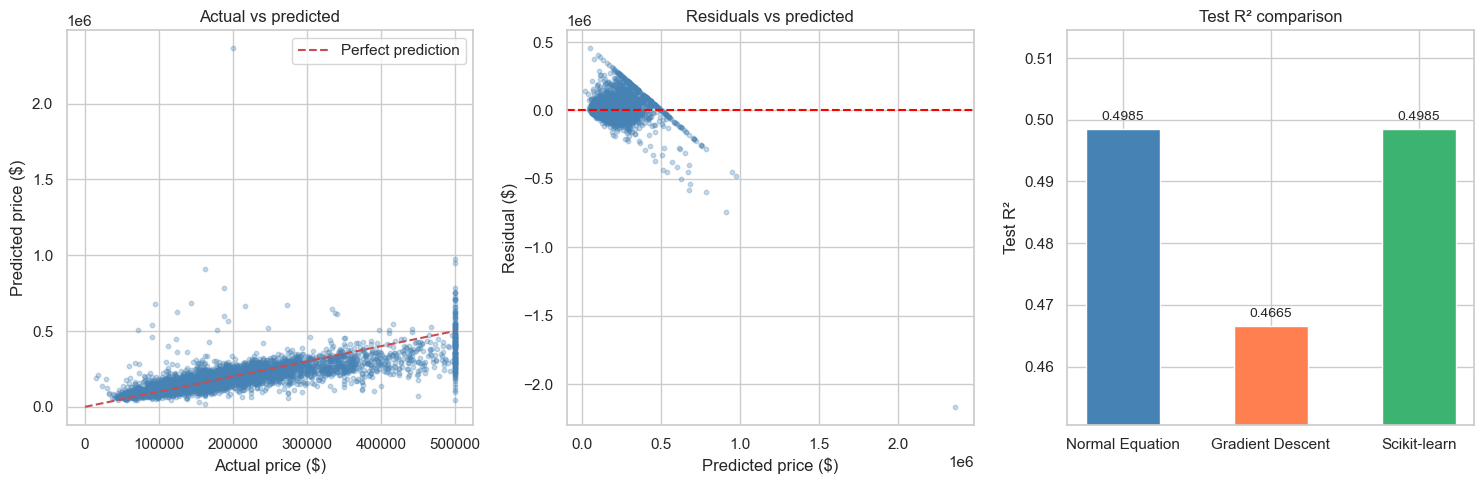

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Actual vs Predicted
axes[0].scatter(np.expm1(y_test), test_preds, alpha=0.3, s=10, color='steelblue')
axes[0].plot([0, 500000], [0, 500000], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual price ($)')
axes[0].set_ylabel('Predicted price ($)')
axes[0].set_title('Actual vs predicted')
axes[0].legend()

# 2. Residuals plot
residuals = np.expm1(y_test) - test_preds
axes[1].scatter(test_preds, residuals, alpha=0.3, s=10, color='steelblue')
axes[1].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Predicted price ($)')
axes[1].set_ylabel('Residual ($)')
axes[1].set_title('Residuals vs predicted')

# 3. Three-way metric comparison
methods = ['Normal Equation', 'Gradient Descent', 'Scikit-learn']
r2_scores = [test_metrics['R2'], test_metrics_gd['R2'], test_metrics_sk['R2']]
colors = ['steelblue', 'coral', 'mediumseagreen']
bars = axes[2].bar(methods, r2_scores, color=colors, width=0.5)

min_score = min(r2_scores)
max_score = max(r2_scores)
padding = (max_score - min_score) * 0.5
axes[2].set_ylim(min_score - padding, max_score + padding)

axes[2].set_ylabel('Test R²')
axes[2].set_title('Test R² comparison')
for bar, score in zip(bars, r2_scores):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{score:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Limitations:

1. Linear assumption: The model assumes a straight-line relationship between every feature and the target. House prices are driven by complex non-linear interactions. For example, the relationship between location (latitude/longitude) and price is geographic and spatial, not linear. A linear model cannot capture this without explicit transformation ie. polynomial features or interaction terms could partially address this within a linear framework.

2. Hard cap at `$500,001` The target variable is artificially capped. Any house worth more than `$500,000` was recorded as `$500,000`, creating an artificial ceiling. The model cannot predict prices above this threshold and the regression line is biased upward in the high-value range because of the mass of clipped values.

3. OLS assumes constant variance in the residuals across all predicted values. In practice, the residuals for this model are likely larger at higher price ranges, both because housing price variance naturally scales with price, and because the `$500,001` cap clusters a mass of clipped values at the ceiling, creating a systematic error pattern the model cannot account for. A weighted least squares approach or a log-transformed target (which partially stabilizes variance) would be more appropriate. The log transform on the target was applied here, but the cap means it only partially corrects the issue.

4. housing_median_age also capped at 52 years. This is called censoring, the same statistical phenomenon as the target ceiling, just on a feature. Any neighborhood older than 52 years was grouped into the same bin (in histogram plots), introducing the same distortion for that feature.

5. Residual multicollinearity even after feature engineering and dropping redundant columns, the model still converged at 16/16 rank only after dropping multiple features. The remaining features (log-transformed originals alongside ratio features) are still correlated to some degree.

6. Ratio features are sensitive to unrealistic inputs. As demonstrated during prediction, rooms_per_household and population_per_household are computed from raw inputs and push predictions wildly off when supplied with values outside the training distribution. The .clip() method applied during training partially mitigates this but doesn't eliminate it entirely. Another internal guard in the model is the assert statements, to aid the mitigation of same.

7. Geographic features are weak linear predictors. Longitude and latitude are included as raw numeric values. Their relationship with price is spatial and non-linear. A house at longitude -122 is not simply "worth more" than one at -120. The model treats them as linear, which is an oversimplification.

8. Ocean proximity is coarse. The ocean_proximity categories are broad geographic labels. Two houses both labeled <1H OCEAN could be in very different neighborhoods with very different prices. A continuous distance-to-coast feature would carry more signal.

9. Model explains only ~49% of variance on test data. An R² of 0.4985 on the test set means roughly 51% of the variation in house prices is unexplained by the model. That's a significant portion of information the model is simply missing.

10. The Random Forest score of 0.835 is itself an imperfect ceiling. It's a single un-tuned run with default hyperparameters. A tuned RF or gradient boosting model (XGBoost, LightGBM) would likely push that further, probably into the 0.85–0.88 range. So even 0.835 understates how much headroom a non-linear model has over this linear model.

11. The two methods (Normal Equation vs gradient descent) produced slightly different test metrics (R² of 0.4985 vs 0.4665). In theory they should converge to the same solution. The difference suggests gradient descent stopped early via tolerance, acting as implicit regularization, which means neither solution is the pure OLS optimum.

12. No regularization. The model uses plain OLS with no Ridge or Lasso penalty. With 16 features and some remaining collinearity, regularization would help stabilize the coefficients and potentially improve generalization. Ridge regression would be the natural next step given the multicollinearity observed.

13. Missing value imputation affects bedrooms. The 207 missing values in total_bedrooms were filled with the median. Since total_bedrooms_log ended up in the final feature matrix, those imputed rows introduce a small systematic bias for that feature. Imputing on the full dataset before splitting technically introduced a minor form of data leakage since the median was computed on all 20,640 rows including test samples. A better approach would be to compute the median strictly on the training fold and apply it to the test fold separately.

14. Block-level data, not individual houses. The dataset describes census blocks, not individual properties. median_house_value is the median of all houses in a block, not the price of a specific house. Predicting the price of a single new house using block-level aggregate features is an ecological fallacy — the prediction represents what a block might look like, not what any one house would sell for.

15. The California Housing dataset is based on the 1990 census. Income figures in the dataset are in 1990 dollars. House prices, income distributions, and neighborhood compositions have changed dramatically since then, making the model unsuitable for real-world predictions in the current market. 

# Conclusion

This project implemented a multiple linear regression model from scratch using NumPy to predict median house values across California census blocks.

Two optimization methods were developed and compared: the Normal Equation solved via np.linalg.lstsq and Batch Gradient Descent with early stopping. Both are grounded in the Ordinary Least Squares framework and were derived mathematically from first principles. Afterwards, Scikit-Learn was used, for comparison.

The pipeline involved several preprocessing decisions. Missing values in total_bedrooms were imputed with the median to preserve training data. Log transformations were applied to right-skewed features and the target variable to reduce skewness and stabilize variance, improving the distributional properties of the residuals, thereby reducing target skewness from strongly right-skewed to approximately -0.17. 

The ocean_proximity categorical variable was one-hot encoded, ratio-based features were engineered to capture housing density and occupancy patterns, and the dummy variable trap was resolved by dropping the ISLAND category, which was justified by its negligible sample count.

A data leakage issue: median_house_value_log appearing in the feature matrix was identified through suspiciously perfect R² scores and corrected mid-development.
The final model achieved a test R² of approximately 0.4985 under the Normal Equation and 0.4665 under Gradient Descent, with test RMSE values of roughly `$81,065` and `$83,609` respectively. The gradient descent learning curve confirmed smooth, stable convergence by iteration 788, with the bulk of learning occurring within the first 50 iterations.

These results are consistent with what linear regression can realistically achieve on this dataset. Median income emerged as the dominant predictor, consistent with a Pearson correlation of approximately 0.68 with the target, while geographic proximity to the ocean provided meaningful categorical signal. The model's ceiling is ultimately defined by its linear assumption. House prices are shaped by complex spatial, economic, and structural interactions that a linear model can only approximate.

To push performance further, future work should explore non-linear models such as Random Forest or Gradient Boosted Trees, incorporate distance-based geographic features, apply Ridge or Lasso regularization to stabilize coefficients, address the artificial `$500,001` cap either by dropping capped rows or treating the problem as a censored regression, and handle missing value imputation strictly within the training fold to eliminate the minor data leakage introduced by median imputation on the full dataset.

This ground-up implementation of linear regression covers data cleaning, feature engineering, mathematical derivation, two optimization methods (excluding the Scikit-Learn implementation), and full evaluation.